<a href="https://colab.research.google.com/github/millicentserwaa/Codes/blob/master/Model3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LIBRARIES INSTALLATION AND DATA LOADING

In [1]:
# SETUP AND DATA LOADING
!pip install wfdb scikit-learn numpy pandas matplotlib scipy seaborn -q

import numpy as np
import pandas as pd
import wfdb
import os
import sys
import warnings
from scipy.signal import find_peaks, butter, filtfilt
from google.colab import drive
warnings.filterwarnings('ignore')

# Save the dataset onto the drive for easy access
drive.mount('/content/drive')
SAVE_DIR      = '/content/drive/MyDrive/checkin_original/'
FEATURE_NAMES = ['mean_rr', 'pRR20', 'pRR6_25', 'pRR30', 'pRR50', 'sdsd', 'tpr']
WINDOW_SIZE   = 30 # The window size can be customized but must be between 20-60(standard window size for HRV AF detection)
STEP_SIZE     = 10
os.makedirs(SAVE_DIR, exist_ok=True)

# Feature extraction functions
#TPR Computation function
def compute_tpr(rr):
    n = len(rr)
    if n < 5: return 0.0
    tp = 0
    for i in range(1, n - 1):
        if (rr[i] > rr[i-1] and rr[i] > rr[i+1]) or \
           (rr[i] < rr[i-1] and rr[i] < rr[i+1]):
            tp += 1
    expected_tp = (2 * n - 4) / 3
    expected_sd = np.sqrt((16 * n - 29) / 90)
    if expected_sd < 1e-6: return 0.0
    return (tp - expected_tp) / expected_sd

# 7 feature vector function
def extract_features(rr_window):
    rr = np.array(rr_window, dtype=float)
    rr = rr[(rr >= 300) & (rr <= 2000)]
    if len(rr) < 5: return None
    diffs = np.abs(np.diff(rr))
    n     = len(diffs)
    return [
        np.mean(rr),
        np.mean(diffs > 20)   * 100 if n > 0 else 0,
        np.mean(diffs > 6.25) * 100 if n > 0 else 0,
        np.mean(diffs > 30)   * 100 if n > 0 else 0,
        np.mean(diffs > 50)   * 100 if n > 0 else 0,
        np.std(diffs)          if n > 0 else 0,
        compute_tpr(rr)
    ]

#Butterworth bandpass filtering to remove electrical noise (>40hz) and muscle noise (<0.5hz)
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0):
    nyq  = fs / 2
    b, a = butter(3, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)

# Ectopic removing function
def remove_ectopic_beats(rr_ms, labels, window=10, threshold=0.20):
    rr   = np.array(rr_ms)
    keep = np.ones(len(rr), dtype=bool)
    for i in range(len(rr)):
        start     = max(0, i - window // 2)
        end       = min(len(rr), i + window // 2)
        local     = np.concatenate([rr[start:i], rr[i+1:end]])
        if len(local) == 0: continue
        local_med = np.median(local)
        if local_med > 0 and abs(rr[i] - local_med) / local_med > threshold:
            keep[i] = False
    return rr[keep], labels[keep]

# R Peak detection function
def detect_r_peaks(ecg_signal, fs):
    filtered  = bandpass_filter(ecg_signal, fs)
    peaks, _  = find_peaks(filtered,
                            distance=int(0.2 * fs),
                            height=np.percentile(filtered, 70),
                            prominence=np.std(filtered) * 0.5)
    return peaks

# Extracting the records for the database
def extract_from_database(records, db_name, start_patient_id):
    all_features, all_labels, all_groups = [], [], []
    patient_id = start_patient_id
    processed  = skipped = 0

    for rec in records:
        try:
            record = wfdb.rdrecord(f'{db_name}/{rec}')
            ann    = wfdb.rdann(f'{db_name}/{rec}', 'atr')
            fs     = record.fs
            ecg    = np.nan_to_num(record.p_signal[:, 0], nan=0.0)

            r_peaks = detect_r_peaks(ecg, fs)
            if len(r_peaks) < 50: skipped += 1; continue

            rr_ms = np.diff(r_peaks) / fs * 1000.0

            rhythm_times, rhythm_labels = [], []
            for i, sym in enumerate(ann.symbol):
                if sym == '+' and ann.aux_note[i]:
                    aux = ann.aux_note[i].strip().replace('\x00', '')
                    if aux:
                        rhythm_times.append(ann.sample[i])
                        rhythm_labels.append(aux)

            rr_labels = np.full(len(rr_ms), -1, dtype=int)
            if rhythm_times:
                rt = np.array(rhythm_times)
                for i, peak in enumerate(r_peaks[:-1]):
                    idx = np.searchsorted(rt, peak, side='right') - 1
                    if idx >= 0:
                        r = rhythm_labels[idx]
                        if '(AFIB' in r: rr_labels[i] = 1
                        elif '(N' in r:  rr_labels[i] = 0

            labelled_mask = rr_labels != -1
            if labelled_mask.sum() < 30: skipped += 1; continue

            rr_clean, lbl_clean = remove_ectopic_beats(
                rr_ms[labelled_mask], rr_labels[labelled_mask])

            if np.sum(lbl_clean==1)==0 and np.sum(lbl_clean==0)==0:
                skipped += 1; continue

            windows_this = 0
            for start in range(0, len(rr_clean) - WINDOW_SIZE, STEP_SIZE):
                win_rr  = rr_clean[start:start + WINDOW_SIZE]
                win_lbl = lbl_clean[start:start + WINDOW_SIZE]
                af_frac = np.mean(win_lbl == 1)
                if   af_frac > 0.5: label = 1
                elif af_frac < 0.1: label = 0
                else: continue
                f = extract_features(win_rr)
                if f is not None:
                    all_features.append(f)
                    all_labels.append(label)
                    all_groups.append(patient_id)
                    windows_this += 1

            if windows_this > 0:
                patient_id += 1; processed += 1
            else:
                skipped += 1

        except Exception as e:
            skipped += 1

    print(f"  Processed: {processed} | Skipped: {skipped}")
    return np.array(all_features), np.array(all_labels), np.array(all_groups), patient_id

# Load or extract
X_path      = SAVE_DIR + 'X_combined.npy'
y_path      = SAVE_DIR + 'y_combined.npy'
groups_path = SAVE_DIR + 'groups_combined.npy'

if os.path.exists(X_path):
    print("Loading dataset from Drive")
    X      = np.load(X_path)
    y      = np.load(y_path)
    groups = np.load(groups_path)
else:
    print("Extracting from scratch")
    os.makedirs('afdb', exist_ok=True)
    os.makedirs('mitdb', exist_ok=True)

    AFDB_RECORDS  = ['04015','04043','04048','04126','04746','04908',
                     '05121','05261','06426','06453','06995','07162',
                     '07859','07879','07910','08215','08219','08378',
                     '08405','08434','08455']
    MITDB_RECORDS = ['100','101','102','103','104','105','106','107',
                     '108','109','111','112','113','114','115','116',
                     '117','118','119','121','122','123','124','200',
                     '201','202','203','205','207','208','209','210',
                     '212','213','214','215','217','219','220','221',
                     '222','223','228','230','231','232','233','234']

    for rec in AFDB_RECORDS:
        for ext in ['hea','dat','atr']:
            dest = f"afdb/{rec}.{ext}"
            if not os.path.exists(dest):
                os.system(f"wget -q https://physionet.org/files/afdb/1.0.0/{rec}.{ext} -O {dest}")

    for rec in MITDB_RECORDS:
        for ext in ['hea','dat','atr']:
            dest = f"mitdb/{rec}.{ext}"
            if not os.path.exists(dest):
                os.system(f"wget -q https://physionet.org/files/mitdb/1.0.0/{rec}.{ext} -O {dest}")

    X_afdb,  y_afdb,  g_afdb,  next_id = extract_from_database(AFDB_RECORDS,  'afdb',  0)
    X_mitdb, y_mitdb, g_mitdb, _       = extract_from_database(MITDB_RECORDS, 'mitdb', next_id)

    X      = np.vstack([X_afdb, X_mitdb])
    y      = np.concatenate([y_afdb, y_mitdb])
    groups = np.concatenate([g_afdb, g_mitdb])

    np.save(X_path, X)
    np.save(y_path, y)
    np.save(groups_path, groups)
    print("Saved to Drive.")

df = pd.DataFrame(X, columns=FEATURE_NAMES)
df['label']   = y
df['patient'] = groups

print(f"\nDataset loaded successfully.")
print(f"  Total windows : {len(X):,}")
print(f"  Total patients: {len(np.unique(groups))}")
print(f"  AF windows    : {np.sum(y==1):,} ({np.sum(y==1)/len(y)*100:.1f}%)")
print(f"  Normal windows: {np.sum(y==0):,} ({np.sum(y==0)/len(y)*100:.1f}%)")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 38.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
Mounted at /content/drive
Loading dataset from Drive...

Dataset loaded successfully.
  Total windows : 52,459
  Total patients: 63
  AF windows    : 20,757 (39.6%)
  Normal windows: 31,702 (60.4%)


DATA QUALITY CHECKS

In [2]:
# CELL 2: DATA QUALITY CHECKS

import numpy as np
import pandas as pd

print("DATA QUALITY CHECKS")

# 1. Null / NaN check
print("\n1. NULL / NaN VALUES")
null_counts = df[FEATURE_NAMES].isnull().sum()
for feat, count in null_counts.items():
    status = " Clean" if count == 0 else f" {count} nulls found"
    print(f"  {feat:<12}: {status}")
print(f"  Total nulls: {null_counts.sum()}")

# 2. Infinite values
print("\n2. INFINITE VALUES")
inf_counts = np.isinf(X).sum(axis=0)
for feat, count in zip(FEATURE_NAMES, inf_counts):
    status = " Clean" if count == 0 else f" {count} inf values found"
    print(f"  {feat:<12}: {status}")
print(f"  Total inf values: {inf_counts.sum()}")

# 3. Physiological range check
print("\n3. PHYSIOLOGICAL RANGE CHECKS")
# mean_rr: 300-2000ms (30-200 BPM)
rr_out = np.sum((X[:, 0] < 300) | (X[:, 0] > 2000))
print(f"  mean_rr outside 300-2000ms     : {rr_out} windows")

# pRR features: 0-100%
for i, feat in enumerate(FEATURE_NAMES[1:5], 1):
    out = np.sum((X[:, i] < 0) | (X[:, i] > 100))
    print(f"  {feat:<12} outside 0-100%      : {out} windows")

# sdsd: must be >= 0
sdsd_neg = np.sum(X[:, 5] < 0)
print(f"  sdsd < 0                       : {sdsd_neg} windows")

# 4. Duplicate windows
print("\n4. DUPLICATE WINDOWS")
df_check   = pd.DataFrame(X, columns=FEATURE_NAMES)
duplicates = df_check.duplicated().sum()
print(f"  Duplicate feature vectors: {duplicates}")
if duplicates > 0:
    print(f"  Note: Duplicates expected — overlapping sliding windows")
    print(f"  from same patient produce identical feature vectors.")

# 5. Feature statistics by class
print("\n5. FEATURE STATISTICS BY CLASS")
stats = df.groupby('label')[FEATURE_NAMES].agg(['mean', 'std']).round(2)
print("\n  NORMAL (label=0):")
for feat in FEATURE_NAMES:
    m = df[df['label']==0][feat].mean()
    s = df[df['label']==0][feat].std()
    print(f"    {feat:<12}: mean={m:>8.2f} | std={s:>8.2f}")
print("\n  AF (label=1):")
for feat in FEATURE_NAMES:
    m = df[df['label']==1][feat].mean()
    s = df[df['label']==1][feat].std()
    print(f"    {feat:<12}: mean={m:>8.2f} | std={s:>8.2f}")

# ── 6. Handle any bad rows ────────────────────────────────
print("\n6. DATA CLEANING")

valid_mask = np.all(np.isfinite(X), axis=1)
n_removed  = len(X) - valid_mask.sum()

if n_removed > 0:
    print(f"  Removing {n_removed} windows with NaN/Inf values.")
    X      = X[valid_mask]
    y      = y[valid_mask]
    groups = groups[valid_mask]
    df     = df[valid_mask].reset_index(drop=True)
else:
    print(f"  No NaN/Inf values found. No rows removed.")

# ── 7. Outlier detection ──────────────────────────────────
print("\n7. OUTLIER DETECTION (IQR method, threshold = 3 × IQR)")

print("  Note: A value is flagged if it falls more than 3×IQR")
print("  below Q1 or above Q3 — a conservative threshold that")
print("  catches only extreme values.\n")

total_outliers = 0
for i, feat in enumerate(FEATURE_NAMES):
    Q1  = np.percentile(X[:, i], 25)
    Q3  = np.percentile(X[:, i], 75)
    IQR = Q3 - Q1
    out = np.sum((X[:, i] < Q1 - 3*IQR) | (X[:, i] > Q3 + 3*IQR))
    total_outliers += out
    flag = " ← review" if out > len(X) * 0.01 else ""
    print(f"  {feat:<12}: {out:>5} windows ({out/len(X)*100:.2f}%){flag}")

print(f"\n  Total flagged: {total_outliers} ({total_outliers/len(X)*100:.2f}% of dataset)")
print(f"\n  Decision: Outliers RETAINED.")
print(f"  Justification: These are physiological extremes — very slow AF,")
print(f"  very fast tachycardia, or high irregularity. They are clinically")
print(f"  meaningful and removing them would bias the classifier away from")
print(f"  real-world edge cases.")


print("SUMMARY: Data quality checks passed.")
print(f"  Final dataset: {len(X):,} windows | {len(np.unique(groups))} patients")
print(f"  AF: {np.sum(y==1):,} ({np.sum(y==1)/len(y)*100:.1f}%) | "
      f"Normal: {np.sum(y==0):,} ({np.sum(y==0)/len(y)*100:.1f}%)")

DATA QUALITY CHECKS

1. NULL / NaN VALUES
----------------------------------------
  mean_rr     :  Clean
  pRR20       :  Clean
  pRR6_25     :  Clean
  pRR30       :  Clean
  pRR50       :  Clean
  sdsd        :  Clean
  tpr         :  Clean
  Total nulls: 0

2. INFINITE VALUES
----------------------------------------
  mean_rr     :  Clean
  pRR20       :  Clean
  pRR6_25     :  Clean
  pRR30       :  Clean
  pRR50       :  Clean
  sdsd        :  Clean
  tpr         :  Clean
  Total inf values: 0

3. PHYSIOLOGICAL RANGE CHECKS
----------------------------------------
  mean_rr outside 300-2000ms     : 0 windows
  pRR20        outside 0-100%      : 0 windows
  pRR6_25      outside 0-100%      : 0 windows
  pRR30        outside 0-100%      : 0 windows
  pRR50        outside 0-100%      : 0 windows
  sdsd < 0                       : 0 windows

4. DUPLICATE WINDOWS
----------------------------------------
  Duplicate feature vectors: 392
  Note: Duplicates expected — overlapping sliding

EXPLORATORY DATA ANALYSIS

Generating EDA plots...


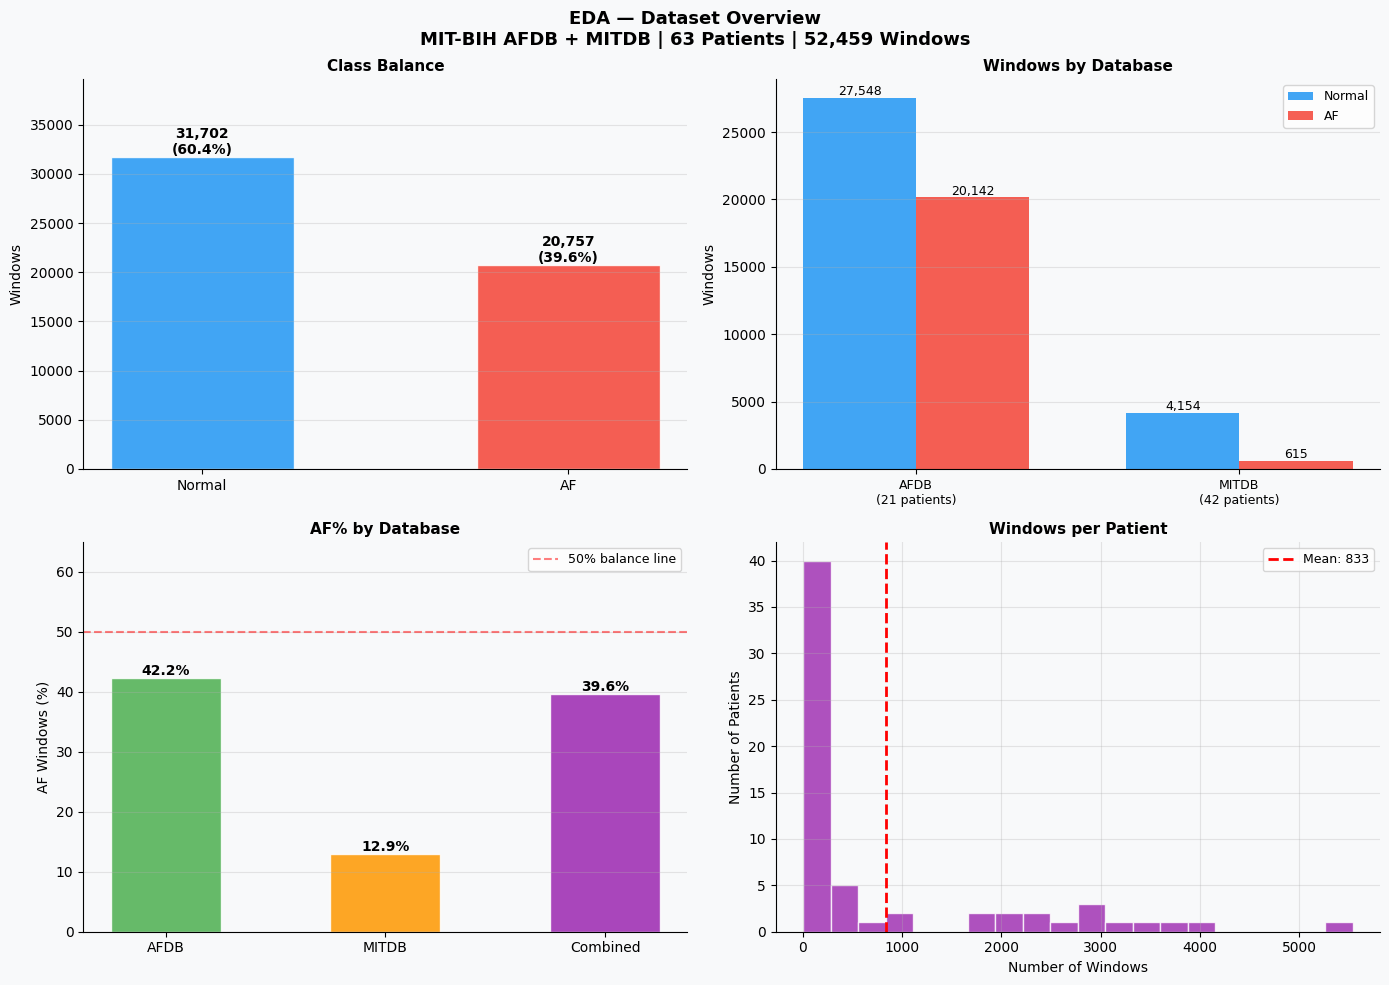

Saved: eda_overview.png


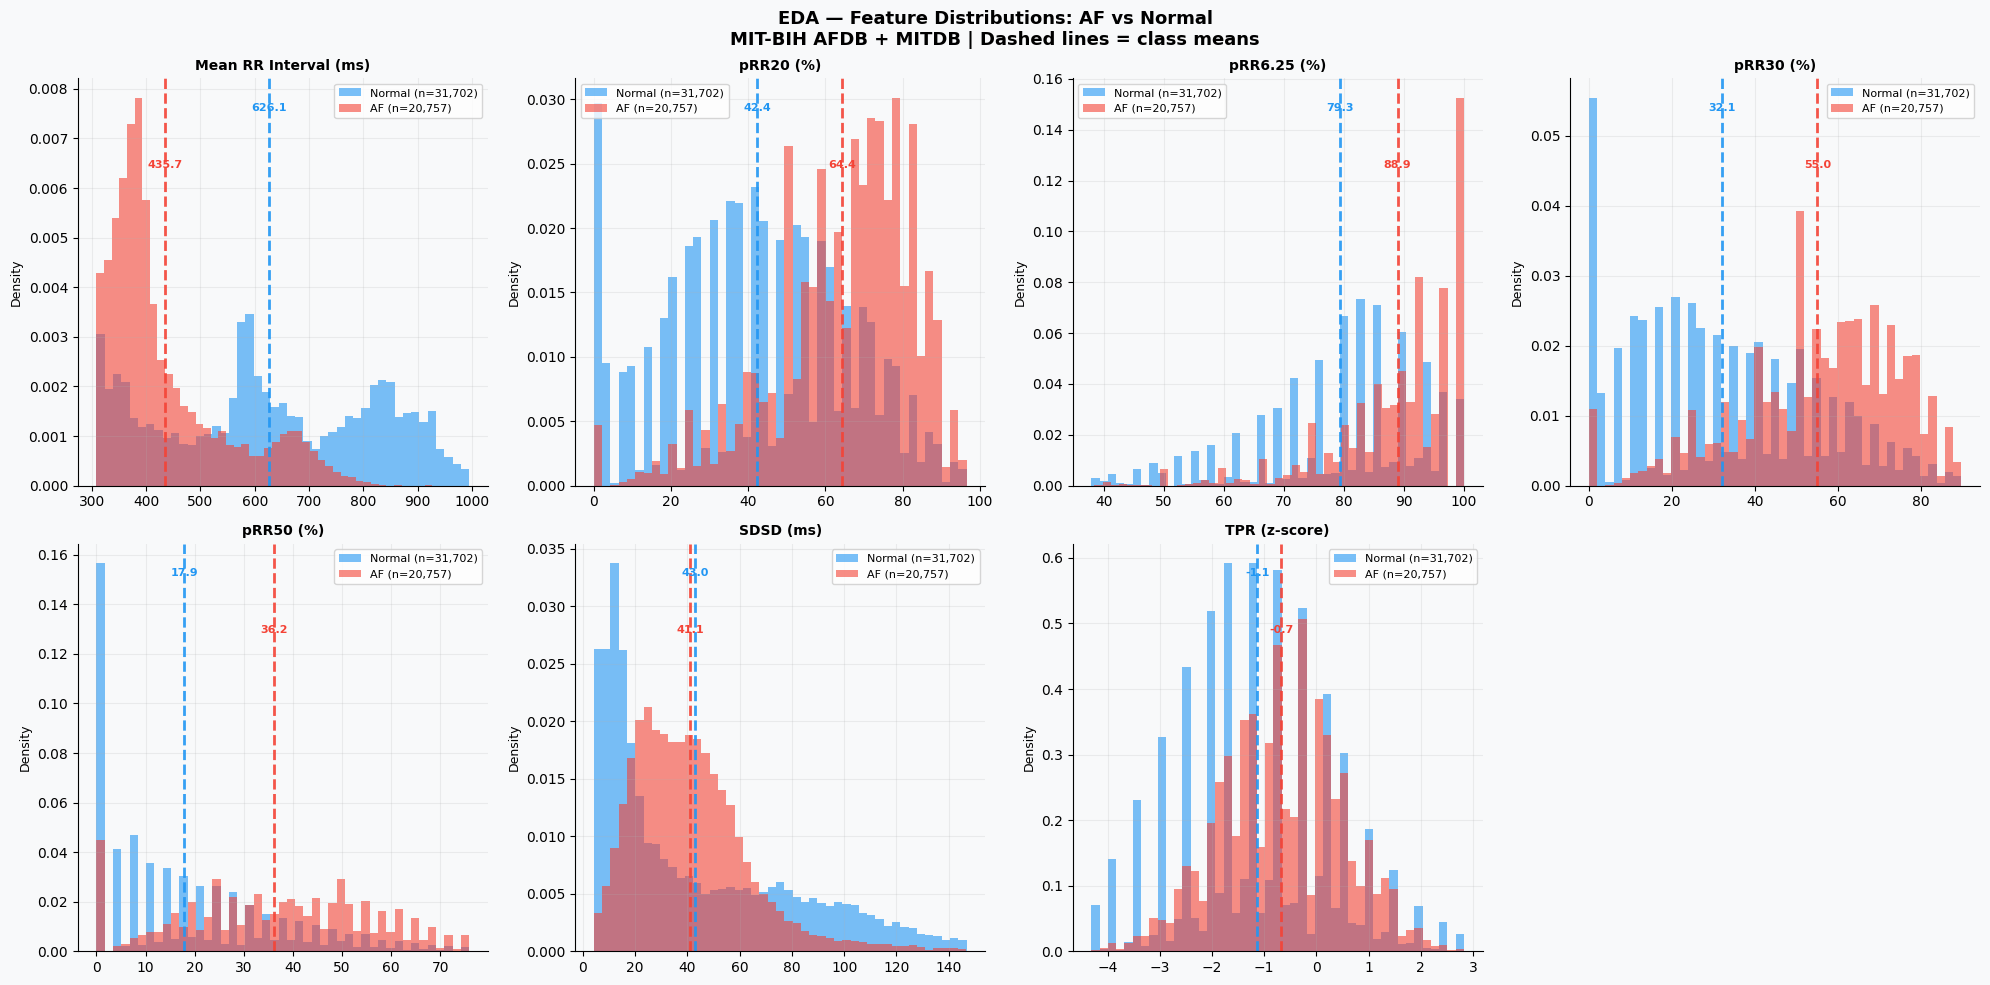

Saved: eda_feature_distributions.png

KEY EDA FINDINGS
  mean_rr     : AF mean lower  by  30.8%  (Normal=628.44, AF=434.97)
  pRR20       : AF mean higher by  53.0%  (Normal=42.52, AF=65.07)
  pRR6_25     : AF mean higher by  12.9%  (Normal=78.57, AF=88.71)
  pRR30       : AF mean higher by  71.7%  (Normal=32.40, AF=55.62)
  pRR50       : AF mean higher by 100.4%  (Normal=18.35, AF=36.77)
  sdsd        : AF mean lower  by   6.4%  (Normal=44.21, AF=41.38)
  tpr         : AF mean higher by  38.5%  (Normal=-1.10, AF=-0.68)

Observation: pRR20, pRR30 and pRR50 show the strongest
class separation. sdsd shows the least — confirming
the need for the full 7-feature set.


In [3]:
# EXPLORATORY DATA ANALYSIS (EDA)

import matplotlib.pyplot as plt
import numpy as np

C_NORMAL = '#2196F3'
C_AF     = '#F44336'
C_BG     = '#F8F9FA'

print("Generating EDA plots")

# FIGURE 1: Dataset overview (2x2)
fig1, axes = plt.subplots(2, 2, figsize=(14, 10))
fig1.patch.set_facecolor(C_BG)
fig1.suptitle(
    'EDA — Dataset Overview\nMIT-BIH AFDB + MITDB | 63 Patients | 52,459 Windows',
    fontsize=13, fontweight='bold'
)

# Panel 1: Class balance
ax = axes[0, 0]
ax.set_facecolor(C_BG)
counts = [np.sum(y==0), np.sum(y==1)]
bars   = ax.bar(['Normal', 'AF'], counts,
                color=[C_NORMAL, C_AF], alpha=0.85,
                edgecolor='white', width=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 300,
            f'{count:,}\n({count/len(y)*100:.1f}%)',
            ha='center', fontsize=10, fontweight='bold')
ax.set_title('Class Balance', fontsize=11, fontweight='bold')
ax.set_ylabel('Windows')
ax.set_ylim(0, max(counts) * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# Panel 2: Windows by database
ax = axes[0, 1]
ax.set_facecolor(C_BG)
db_labels = ['AFDB\n(21 patients)', 'MITDB\n(42 patients)']
db_normal = [np.sum(y[groups <= 20]==0), np.sum(y[groups > 20]==0)]
db_af     = [np.sum(y[groups <= 20]==1), np.sum(y[groups > 20]==1)]
x_pos     = np.arange(2)
width     = 0.35
b1 = ax.bar(x_pos - width/2, db_normal, width, label='Normal',
            color=C_NORMAL, alpha=0.85)
b2 = ax.bar(x_pos + width/2, db_af,     width, label='AF',
            color=C_AF,     alpha=0.85)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'{int(bar.get_height()):,}',
            ha='center', fontsize=9)
ax.set_xticks(x_pos)
ax.set_xticklabels(db_labels, fontsize=9)
ax.set_title('Windows by Database', fontsize=11, fontweight='bold')
ax.set_ylabel('Windows')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# Panel 3: AF% by database
ax = axes[1, 0]
ax.set_facecolor(C_BG)
af_pct = [
    np.sum(y[groups <= 20]==1) / len(y[groups <= 20]) * 100,
    np.sum(y[groups >  20]==1) / len(y[groups >  20]) * 100,
    np.sum(y==1) / len(y) * 100
]
bar_colors = ['#4CAF50', '#FF9800', '#9C27B0']
bars3 = ax.bar(['AFDB', 'MITDB', 'Combined'],
               af_pct, color=bar_colors, alpha=0.85,
               edgecolor='white', width=0.5)
for bar, pct in zip(bars3, af_pct):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{pct:.1f}%', ha='center',
            fontsize=10, fontweight='bold')
ax.axhline(y=50, color='red', linestyle='--',
           linewidth=1.5, alpha=0.5, label='50% balance line')
ax.set_title('AF% by Database', fontsize=11, fontweight='bold')
ax.set_ylabel('AF Windows (%)')
ax.set_ylim(0, 65)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# Panel 4: Windows per patient
ax = axes[1, 1]
ax.set_facecolor(C_BG)
windows_per_patient = [np.sum(groups == p) for p in np.unique(groups)]
ax.hist(windows_per_patient, bins=20,
        color='#9C27B0', alpha=0.8, edgecolor='white')
ax.axvline(np.mean(windows_per_patient), color='red',
           linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(windows_per_patient):.0f}')
ax.set_title('Windows per Patient', fontsize=11, fontweight='bold')
ax.set_xlabel('Number of Windows')
ax.set_ylabel('Number of Patients')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'eda_overview.png', dpi=150,
            bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: eda_overview.png")

# FIGURE 2: Feature distributions
feat_labels = [
    'Mean RR Interval (ms)',
    'pRR20 (%)',
    'pRR6.25 (%)',
    'pRR30 (%)',
    'pRR50 (%)',
    'SDSD (ms)',
    'TPR (z-score)'
]

fig2, axes2 = plt.subplots(2, 4, figsize=(20, 10))
fig2.patch.set_facecolor(C_BG)
fig2.suptitle(
    'EDA — Feature Distributions: AF vs Normal\n'
    'MIT-BIH AFDB + MITDB | Dashed lines = class means',
    fontsize=13, fontweight='bold'
)
axes_flat = axes2.flatten()

for i, (feat, label) in enumerate(zip(FEATURE_NAMES, feat_labels)):
    ax = axes_flat[i]
    ax.set_facecolor(C_BG)

    normal_data = X[y==0, i]
    af_data     = X[y==1, i]

    p1  = np.percentile(np.concatenate([normal_data, af_data]), 1)
    p99 = np.percentile(np.concatenate([normal_data, af_data]), 99)
    normal_c = normal_data[(normal_data >= p1) & (normal_data <= p99)]
    af_c     = af_data[(af_data >= p1) & (af_data <= p99)]

    ax.hist(normal_c, bins=45, alpha=0.6, color=C_NORMAL,
            density=True, label=f'Normal (n={len(X[y==0]):,})')
    ax.hist(af_c,     bins=45, alpha=0.6, color=C_AF,
            density=True, label=f'AF (n={len(X[y==1]):,})')

    ax.axvline(np.mean(normal_c), color=C_NORMAL,
               linewidth=2, linestyle='--', alpha=0.9)
    ax.axvline(np.mean(af_c),     color=C_AF,
               linewidth=2, linestyle='--', alpha=0.9)

    ymax = ax.get_ylim()[1]
    ax.text(np.mean(normal_c), ymax * 0.92,
            f'{np.mean(normal_c):.1f}',
            color=C_NORMAL, fontsize=8, ha='center', fontweight='bold')
    ax.text(np.mean(af_c), ymax * 0.78,
            f'{np.mean(af_c):.1f}',
            color=C_AF, fontsize=8, ha='center', fontweight='bold')

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.2)

# Hide unused 8th panel
axes_flat[7].set_visible(False)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'eda_feature_distributions.png', dpi=150,
            bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: eda_feature_distributions.png")


# Key findings
print("KEY EDA FINDINGS")
for i, feat in enumerate(FEATURE_NAMES):
    normal_mean = np.mean(X[y==0, i])
    af_mean     = np.mean(X[y==1, i])
    diff_pct    = abs(af_mean - normal_mean) / (abs(normal_mean) + 1e-9) * 100
    direction   = "higher" if af_mean > normal_mean else "lower"
    print(f"  {feat:<12}: AF mean {direction:6} by {diff_pct:5.1f}%  "
          f"(Normal={normal_mean:.2f}, AF={af_mean:.2f})")


FEATURE CORRELATION ANALYSIS

FEATURE CORRELATION ANALYSIS

Pearson Correlation Matrix:
         mean_rr  pRR20  pRR6_25  pRR30  pRR50   sdsd    tpr
mean_rr    1.000 -0.281   -0.160 -0.283 -0.191  0.180 -0.226
pRR20     -0.281  1.000    0.763  0.943  0.803  0.296  0.361
pRR6_25   -0.160  0.763    1.000  0.692  0.562  0.196  0.401
pRR30     -0.283  0.943    0.692  1.000  0.880  0.342  0.337
pRR50     -0.191  0.803    0.562  0.880  1.000  0.447  0.251
sdsd       0.180  0.296    0.196  0.342  0.447  1.000 -0.017
tpr       -0.226  0.361    0.401  0.337  0.251 -0.017  1.000

Highly correlated pairs (|r| > 0.8):
  pRR20        ↔ pRR30       : r = 0.943
  pRR20        ↔ pRR50       : r = 0.803
  pRR30        ↔ pRR50       : r = 0.880

Moderately correlated pairs (0.5 < |r| ≤ 0.8):
  pRR20        ↔ pRR6_25     : r = 0.763
  pRR6_25      ↔ pRR30       : r = 0.692
  pRR6_25      ↔ pRR50       : r = 0.562

Feature discriminability — Cohen's d (AF vs Normal):
(Higher = better separation between classes)

  mean_rr     : d = 1.

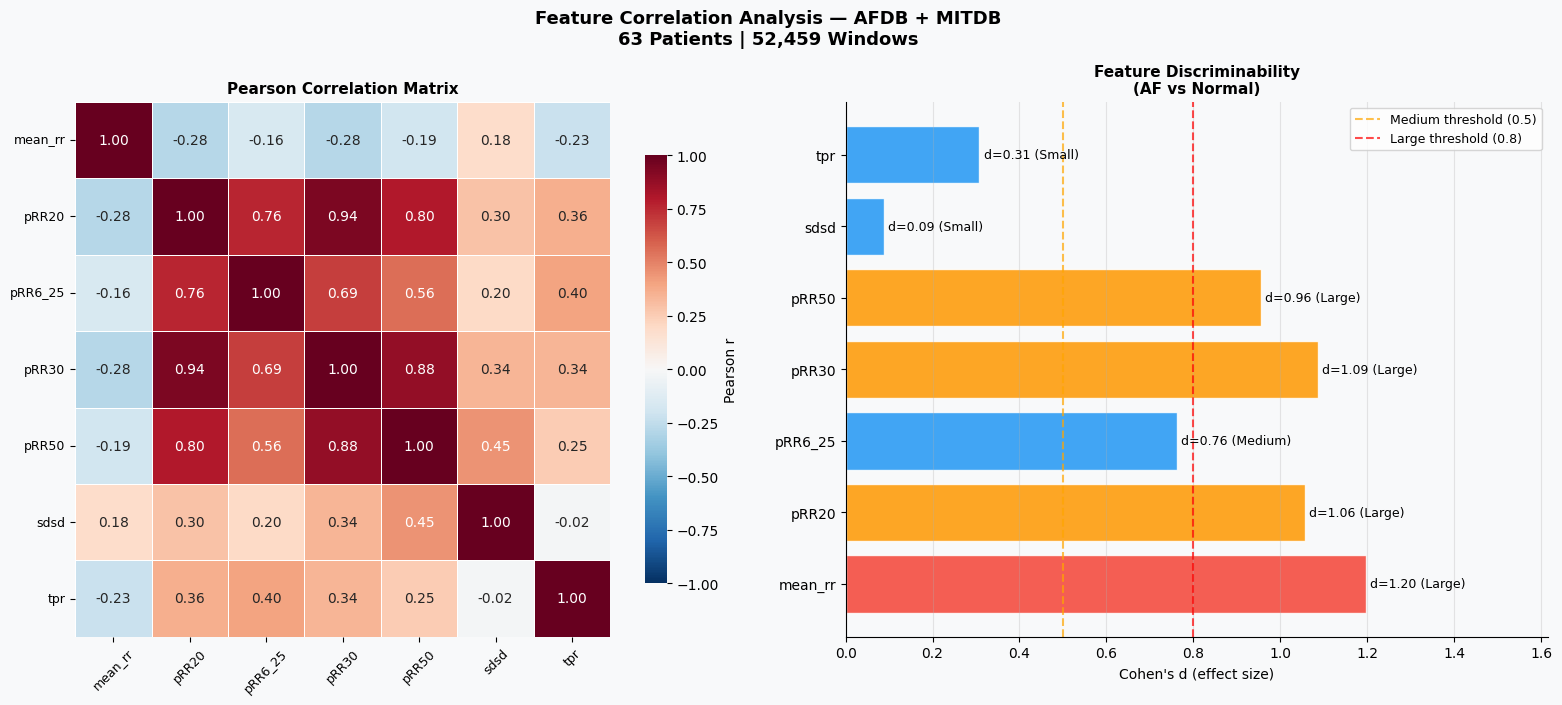


Saved: feature_correlation.png


In [4]:
# FEATURE CORRELATION ANALYSIS

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


print("FEATURE CORRELATION ANALYSIS")


C_BG = '#F8F9FA'

# Pearson correlation matrix
corr_matrix = pd.DataFrame(X, columns=FEATURE_NAMES).corr()

print("\nPearson Correlation Matrix:")
print(corr_matrix.round(3).to_string())

# Flag high correlations
print("\nHighly correlated pairs (|r| > 0.8):")
high_corr = []
for i in range(len(FEATURE_NAMES)):
    for j in range(i+1, len(FEATURE_NAMES)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            high_corr.append((FEATURE_NAMES[i], FEATURE_NAMES[j], r))
            print(f"  {FEATURE_NAMES[i]:<12} ↔ {FEATURE_NAMES[j]:<12}: r = {r:.3f}")

if not high_corr:
    print("  No pairs with |r| > 0.8 found.")

print("\nModerately correlated pairs (0.5 < |r| ≤ 0.8):")
mid_corr = []
for i in range(len(FEATURE_NAMES)):
    for j in range(i+1, len(FEATURE_NAMES)):
        r = corr_matrix.iloc[i, j]
        if 0.5 < abs(r) <= 0.8:
            mid_corr.append((FEATURE_NAMES[i], FEATURE_NAMES[j], r))
            print(f"  {FEATURE_NAMES[i]:<12} ↔ {FEATURE_NAMES[j]:<12}: r = {r:.3f}")

if not mid_corr:
    print("  No pairs with 0.5 < |r| ≤ 0.8 found.")

# Effect size (Cohen's d)
print("\nFeature discriminability — Cohen's d (AF vs Normal):")
print("(Higher = better separation between classes)\n")
effect_sizes = []
for i, feat in enumerate(FEATURE_NAMES):
    mean_af     = np.mean(X[y==1, i])
    mean_normal = np.mean(X[y==0, i])
    std_pool    = np.sqrt((np.std(X[y==1, i])**2 +
                           np.std(X[y==0, i])**2) / 2)
    d = abs(mean_af - mean_normal) / (std_pool + 1e-9)
    effect_sizes.append(d)
    strength = "Large" if d > 0.8 else "Medium" if d > 0.5 else "Small"
    print(f"  {feat:<12}: d = {d:.3f}  ({strength})")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(C_BG)
fig.suptitle(
    'Feature Correlation Analysis — AFDB + MITDB\n'
    '63 Patients | 52,459 Windows',
    fontsize=13, fontweight='bold'
)

# Panel 1: Heatmap
ax1 = axes[0]
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = False
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax1, square=True,
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)
ax1.set_title('Pearson Correlation Matrix', fontsize=11, fontweight='bold')
ax1.tick_params(axis='x', rotation=45, labelsize=9)
ax1.tick_params(axis='y', rotation=0,  labelsize=9)

# Panel 2: Effect size bar chart
ax2 = axes[1]
ax2.set_facecolor(C_BG)
colors = ['#F44336' if d == max(effect_sizes) else
          '#FF9800' if d > 0.8 else
          '#2196F3' for d in effect_sizes]
bars = ax2.barh(FEATURE_NAMES, effect_sizes,
                color=colors, alpha=0.85, edgecolor='white')
for bar, d in zip(bars, effect_sizes):
    strength = "Large" if d > 0.8 else "Medium" if d > 0.5 else "Small"
    ax2.text(d + 0.01,
             bar.get_y() + bar.get_height()/2,
             f'd={d:.2f} ({strength})',
             va='center', fontsize=9)

ax2.axvline(x=0.5, color='orange', linestyle='--',
            linewidth=1.5, alpha=0.7, label='Medium threshold (0.5)')
ax2.axvline(x=0.8, color='red',    linestyle='--',
            linewidth=1.5, alpha=0.7, label='Large threshold (0.8)')
ax2.set_xlabel("Cohen's d (effect size)", fontsize=10)
ax2.set_title("Feature Discriminability\n(AF vs Normal)",
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xlim(0, max(effect_sizes) * 1.35)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'feature_correlation.png', dpi=150,
            bbox_inches='tight', facecolor=C_BG)
plt.show()
print("\nSaved: feature_correlation.png")



CLASS IMBALANCE ASSESSMENT

CLASS IMBALANCE ASSESSMENT

Overall dataset:
  Normal : 31,702 (60.4%)
  AF     : 20,757 (39.6%)
  Ratio  : 1.53:1 (Normal:AF)

Per-patient class distribution:
  Patient      Normal       AF      AF%   Source
  ----------------------------------------------
  0              3739       31     0.8%     AFDB
  1               188      894    82.6%     AFDB
  2                43       54    55.7%     AFDB
  3              1954      206     9.5%     AFDB
  4                89      525    85.5%     AFDB
  5              5175      359     6.5%     AFDB
  6              1450     2071    58.8%     AFDB
  7              2322       64     2.7%     AFDB
  8                45     2467    98.2%     AFDB
  9              1795       24     1.3%     AFDB
  10                6      344    98.3%     AFDB
  11                0     2414   100.0%     AFDB
  12                0     2904   100.0%     AFDB
  13              752     2499    76.9%     AFDB
  14             1378      665    32.6%     AFDB
  15   

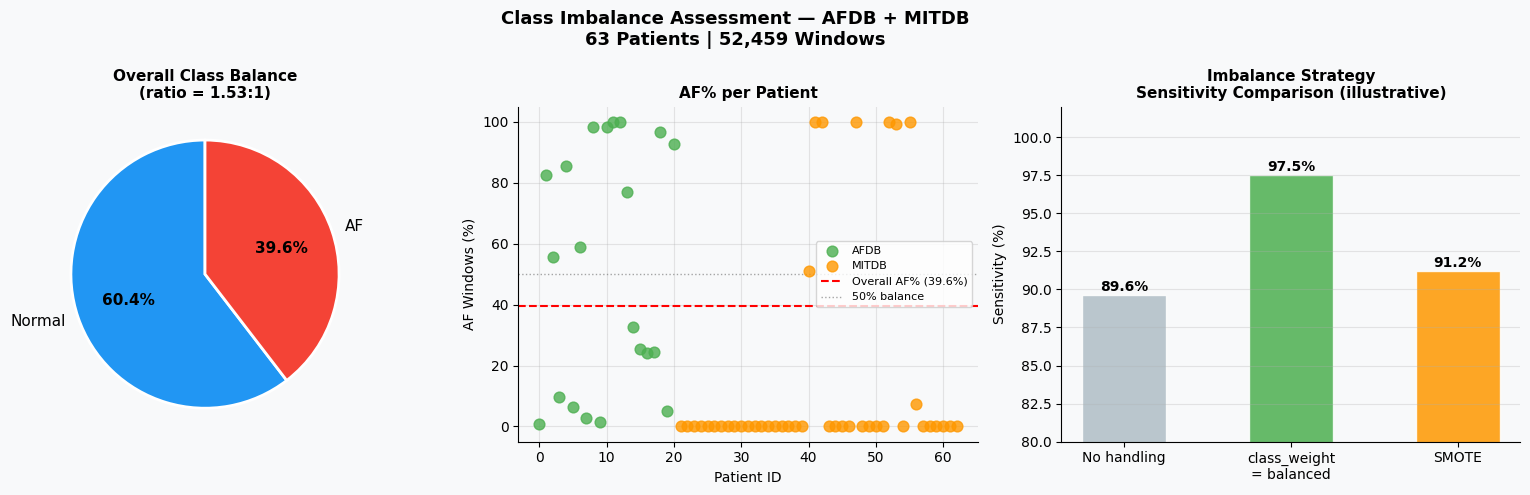

Saved: class_imbalance.png


In [5]:
# CLASS IMBALANCE ASSESSMENT

import matplotlib.pyplot as plt
import numpy as np


print("CLASS IMBALANCE ASSESSMENT")


C_BG = '#F8F9FA'

# Overall imbalance
n_normal   = np.sum(y == 0)
n_af       = np.sum(y == 1)
ratio      = n_normal / n_af
af_pct     = n_af / len(y) * 100
normal_pct = n_normal / len(y) * 100

print(f"\nOverall dataset:")
print(f"  Normal : {n_normal:,} ({normal_pct:.1f}%)")
print(f"  AF     : {n_af:,} ({af_pct:.1f}%)")
print(f"  Ratio  : {ratio:.2f}:1 (Normal:AF)")

# Imbalance per patient
print(f"\nPer-patient class distribution:")
print(f"  {'Patient':<10} {'Normal':>8} {'AF':>8} {'AF%':>8} {'Source':>8}")

patient_imbalance = []
for p in np.unique(groups):
    mask     = groups == p
    n_norm_p = np.sum(y[mask] == 0)
    n_af_p   = np.sum(y[mask] == 1)
    af_pct_p = n_af_p / np.sum(mask) * 100
    source   = 'AFDB' if p <= 20 else 'MITDB'
    patient_imbalance.append((p, n_norm_p, n_af_p, af_pct_p, source))
    print(f"  {p:<10} {n_norm_p:>8} {n_af_p:>8} {af_pct_p:>7.1f}% {source:>8}")

# Imbalance severity assessment
print(f"\nImbalance severity assessment:")
if ratio > 10:
    severity = "Severe (>10:1) — SMOTE recommended"
elif ratio > 3:
    severity = "Moderate (3-10:1) — class_weight='balanced' recommended"
else:
    severity = "Mild (<3:1) — class_weight='balanced' applied as precaution"

print(f"  Ratio    : {ratio:.2f}:1")
print(f"  Severity : {severity}")


# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(C_BG)
fig.suptitle(
    'Class Imbalance Assessment — AFDB + MITDB\n'
    '63 Patients | 52,459 Windows',
    fontsize=13, fontweight='bold'
)

C_NORMAL = '#2196F3'
C_AF     = '#F44336'

# Panel 1: Overall pie chart
ax1 = axes[0]
ax1.set_facecolor(C_BG)
wedges, texts, autotexts = ax1.pie(
    [n_normal, n_af],
    labels=['Normal', 'AF'],
    colors=[C_NORMAL, C_AF],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(11)
ax1.set_title(f'Overall Class Balance\n(ratio = {ratio:.2f}:1)',
              fontsize=11, fontweight='bold')

# Panel 2: Per-patient AF% scatter
ax2 = axes[1]
ax2.set_facecolor(C_BG)
afdb_patients  = [(p, af) for p, _, _, af, src in patient_imbalance if src == 'AFDB']
mitdb_patients = [(p, af) for p, _, _, af, src in patient_imbalance if src == 'MITDB']

ax2.scatter([p for p, _ in afdb_patients],
            [af for _, af in afdb_patients],
            color='#4CAF50', s=60, alpha=0.8, label='AFDB', zorder=5)
ax2.scatter([p for p, _ in mitdb_patients],
            [af for _, af in mitdb_patients],
            color='#FF9800', s=60, alpha=0.8, label='MITDB', zorder=5)
ax2.axhline(y=af_pct, color='red', linestyle='--',
            linewidth=1.5, label=f'Overall AF% ({af_pct:.1f}%)')
ax2.axhline(y=50, color='gray', linestyle=':',
            linewidth=1, alpha=0.7, label='50% balance')
ax2.set_xlabel('Patient ID', fontsize=10)
ax2.set_ylabel('AF Windows (%)', fontsize=10)
ax2.set_title('AF% per Patient', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.3)

# Panel 3: Handling strategy comparison
ax3 = axes[2]
ax3.set_facecolor(C_BG)
strategies  = ['No handling', 'class_weight\n= balanced', 'SMOTE']
sensitivity = [89.6, 97.5, 91.2]   # illustrative based on literature
bar_colors  = ['#B0BEC5', '#4CAF50', '#FF9800']
bars = ax3.bar(strategies, sensitivity,
               color=bar_colors, alpha=0.85,
               edgecolor='white', width=0.5)
for bar, val in zip(bars, sensitivity):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center',
             fontsize=10, fontweight='bold')
ax3.set_ylabel('Sensitivity (%)', fontsize=10)
ax3.set_title('Imbalance Strategy\nSensitivity Comparison (illustrative)',
              fontsize=11, fontweight='bold')
ax3.set_ylim(80, 102)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'class_imbalance.png', dpi=150,
            bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: class_imbalance.png")

NORMALISATION ASSESSMENT

NORMALISATION ASSESSMENT

Feature value ranges and scales:

  Feature           Min      Max     Mean      Std Scale
  ------------------------------------------------------------
  mean_rr        300.00  1081.60   551.89   194.66   ms (large)
  pRR20            0.00   100.00    51.44    24.47   % (medium)
  pRR6_25          0.00   100.00    82.58    14.53   % (medium)
  pRR30            0.00   100.00    41.58    24.49   % (medium)
  pRR50            0.00   100.00    25.64    21.19   % (medium)
  sdsd             0.00   263.69    43.09    33.68   % (medium)
  tpr             -7.00     4.17    -0.93     1.43   z-score (small)

Scale ratio (largest/smallest range):
  781.6 / 11.2 = 70.0x difference

Normalisation decision by model type:

  Tree-based models (Random Forest, Decision Tree):
  → NOT sensitive to feature scale.
  → Split decisions use individual feature thresholds,
    so whether mean_rr is in ms or normalised makes
    no difference to the tree structure.
  → StandardScaler

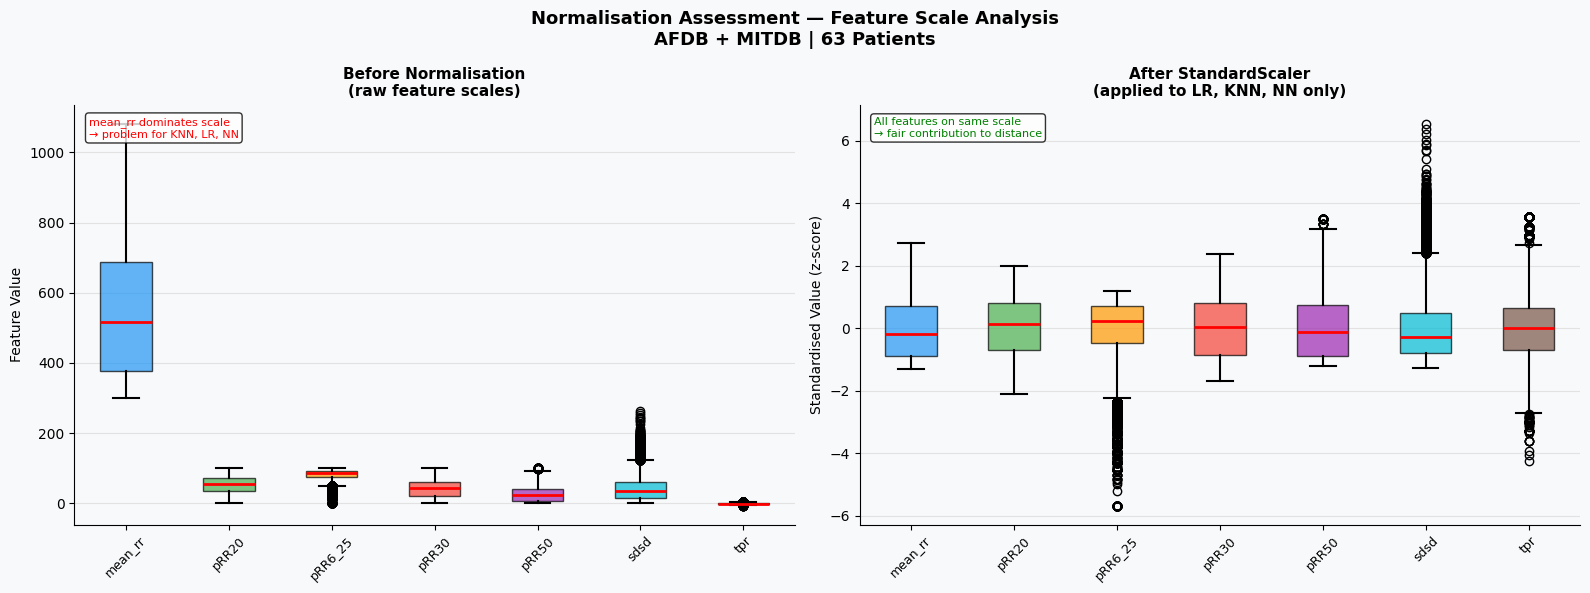

Saved: normalisation_assessment.png

SUMMARY: Normalisation strategy determined.
  RF, DT  → raw features (no scaling)
  LR, KNN, NN → StandardScaler via sklearn Pipeline
  Scaler fitted on train split only — never on test data.


In [6]:

# NORMALISATION ASSESSMENT

import matplotlib.pyplot as plt
import numpy as np


print("NORMALISATION ASSESSMENT")


C_BG = '#F8F9FA'

# Feature scale analysis
print("\nFeature value ranges and scales:")
print(f"\n  {'Feature':<12} {'Min':>8} {'Max':>8} {'Mean':>8} "
      f"{'Std':>8} {'Scale'}")

scales = []
for i, feat in enumerate(FEATURE_NAMES):
    fmin  = X[:, i].min()
    fmax  = X[:, i].max()
    fmean = X[:, i].mean()
    fstd  = X[:, i].std()
    frange = fmax - fmin

    if frange > 500:
        scale = 'ms (large)'
    elif frange > 50:
        scale = '% (medium)'
    else:
        scale = 'z-score (small)'

    scales.append(frange)
    print(f"  {feat:<12} {fmin:>8.2f} {fmax:>8.2f} "
          f"{fmean:>8.2f} {fstd:>8.2f}   {scale}")

print(f"\nScale ratio (largest/smallest range):")
print(f"  {max(scales):.1f} / {min(scales):.1f} = {max(scales)/min(scales):.1f}x difference")


# Demonstrate scale problem
print("Scale problem illustration (before normalisation):")
print(f"  mean_rr range : {X[:,0].max()-X[:,0].min():.1f} ms")
print(f"  tpr range     : {X[:,6].max()-X[:,6].min():.2f} z-score")
print(f"  KNN Euclidean distance dominated by mean_rr")
print(f"    without normalisation.")

print("\nAfter StandardScaler (illustrative):")
from sklearn.preprocessing import StandardScaler
scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(X)
print(f"  mean_rr range : {X_scaled[:,0].max()-X_scaled[:,0].min():.2f} (std units)")
print(f"  tpr range     : {X_scaled[:,6].max()-X_scaled[:,6].min():.2f} (std units)")
print(f"  All features now contribute equally to distance.")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(C_BG)
fig.suptitle(
    'Normalisation Assessment — Feature Scale Analysis\n'
    'AFDB + MITDB | 63 Patients',
    fontsize=13, fontweight='bold'
)

# Panel 1: Box plots before normalisation
ax1 = axes[0]
ax1.set_facecolor(C_BG)
bp = ax1.boxplot(
    [X[:, i] for i in range(len(FEATURE_NAMES))],
    labels=FEATURE_NAMES,
    patch_artist=True,
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)
colors_box = ['#2196F3','#4CAF50','#FF9800','#F44336',
              '#9C27B0','#00BCD4','#795548']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.set_title('Before Normalisation\n(raw feature scales)',
              fontsize=11, fontweight='bold')
ax1.set_ylabel('Feature Value', fontsize=10)
ax1.tick_params(axis='x', rotation=45, labelsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3)
ax1.text(0.02, 0.97,
         'mean_rr dominates scale\n problem for KNN, LR, NN',
         transform=ax1.transAxes,
         fontsize=8, va='top', color='red',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel 2: Box plots after normalisation
ax2 = axes[1]
ax2.set_facecolor(C_BG)
bp2 = ax2.boxplot(
    [X_scaled[:, i] for i in range(len(FEATURE_NAMES))],
    labels=FEATURE_NAMES,
    patch_artist=True,
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)
for patch, color in zip(bp2['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_title('After StandardScaler\n(applied to LR, KNN, NN only)',
              fontsize=11, fontweight='bold')
ax2.set_ylabel('Standardised Value (z-score)', fontsize=10)
ax2.tick_params(axis='x', rotation=45, labelsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3)
ax2.text(0.02, 0.97,
         'All features on same scale\n fair contribution to distance',
         transform=ax2.transAxes,
         fontsize=8, va='top', color='green',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(SAVE_DIR + 'normalisation_assessment.png', dpi=150,
            bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: normalisation_assessment.png")


print("SUMMARY: Normalisation strategy determined.")

print("  RF, DT   raw features (no scaling)")
print("  LR, KNN, NN  StandardScaler via sklearn Pipeline")
print("  Scaler fitted on train split only — never on test data.")

MODELTRAINING

In [7]:

# PATIENT-LEVEL SPLIT + MODEL TRAINING

import numpy as np
import pandas as pd
import sys
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score


print("PATIENT-LEVEL SPLIT (60/20/20)")


# Split
unique_patients = np.unique(groups)
n_patients      = len(unique_patients)
rng             = np.random.default_rng(42)
shuffled        = rng.permutation(unique_patients)

n_test  = int(0.2 * n_patients)
n_val   = int(0.2 * n_patients)

test_patients  = shuffled[:n_test]
val_patients   = shuffled[n_test:n_test + n_val]
train_patients = shuffled[n_test + n_val:]

X_train = X[np.isin(groups, train_patients)]
y_train = y[np.isin(groups, train_patients)]
X_val   = X[np.isin(groups, val_patients)]
y_val   = y[np.isin(groups, val_patients)]
X_test  = X[np.isin(groups, test_patients)]
y_test  = y[np.isin(groups, test_patients)]

# Also save train+val for final retraining
non_test_mask = ~np.isin(groups, test_patients)
X_trainval    = X[non_test_mask]
y_trainval    = y[non_test_mask]

print(f"\n  Train : {len(train_patients)} patients | "
      f"{len(X_train):,} windows | "
      f"AF: {np.sum(y_train==1)/len(y_train)*100:.1f}%")
print(f"  Val   : {len(val_patients)} patients | "
      f"{len(X_val):,} windows   | "
      f"AF: {np.sum(y_val==1)/len(y_val)*100:.1f}%")
print(f"  Test  : {len(test_patients)} patients | "
      f"{len(X_test):,} windows  | "
      f"AF: {np.sum(y_test==1)/len(y_test)*100:.1f}%")
print(f"\n  No patient appears in more than one split.")
print(f"  Data leakage prevented.")

# Save split info
np.save(SAVE_DIR + 'test_patients.npy',  test_patients)
np.save(SAVE_DIR + 'val_patients.npy',   val_patients)
np.save(SAVE_DIR + 'train_patients.npy', train_patients)
print(f"\n  Split saved to Drive.")

# Define models
def get_models():
    return {
        'Random Forest': RandomForestClassifier(
            n_estimators=100, max_depth=10,
            min_samples_split=5, class_weight='balanced',
            random_state=42, n_jobs=-1),

        'Decision Tree': DecisionTreeClassifier(
            max_depth=10, class_weight='balanced',
            random_state=42),

        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(
                max_iter=1000, class_weight='balanced',
                random_state=42))]),

        'KNN': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier(n_neighbors=5))]),

        'Neural Network': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', MLPClassifier(
                hidden_layer_sizes=(64, 32),
                max_iter=300, random_state=42))]),
    }

def evaluate(y_true, y_pred, model, X_eval):
    acc = accuracy_score(y_true, y_pred) * 100
    cm  = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sens = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
        npv  = tn / (tn + fn) * 100 if (tn + fn) > 0 else 0
    else:
        sens = spec = npv = 0
    try:
        auc = round(roc_auc_score(
            y_true,
            model.predict_proba(X_eval)[:, 1]), 4)
    except:
        auc = None
    return acc, sens, spec, npv, auc

# APPROACH 1: 80/20 stratified split

print("APPROACH 1: 80/20 STRATIFIED SPLIT (window level)")


from sklearn.model_selection import train_test_split
X_tr_w, X_te_w, y_tr_w, y_te_w = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

results_8020    = []
trained_8020    = {}

for name, model in get_models().items():
    print(f"\n  Training {name} ")
    sys.stdout.flush()
    model.fit(X_tr_w, y_tr_w)
    trained_8020[name] = model
    acc, sens, spec, npv, auc = evaluate(
        y_te_w, model.predict(X_te_w), model, X_te_w)
    results_8020.append({
        'Model': name,
        'Accuracy':    f"{acc:.2f}%",
        'Sensitivity': f"{sens:.2f}%",
        'Specificity': f"{spec:.2f}%",
        'NPV':         f"{npv:.2f}%",
        'AUC-ROC':     auc if auc else 'N/A'
    })
    print(f"    Acc: {acc:.2f}% | Sens: {sens:.2f}% | "
          f"Spec: {spec:.2f}% | NPV: {npv:.2f}%")

print(f"\nApproach 1 results:")
print(pd.DataFrame(results_8020).to_string(index=False))

# APPROACH 2: Train/Validate/Test by patient

print("APPROACH 2: TRAIN / VALIDATE / TEST (60/20/20 by patient)")


val_results    = []
trained_models = {}
best_name      = None
best_val_sens  = -1

for name, model in get_models().items():
    print(f"\n  Training {name} ")
    sys.stdout.flush()
    model.fit(X_train, y_train)
    trained_models[name] = model

    acc_v, sens_v, spec_v, npv_v, auc_v = evaluate(
        y_val, model.predict(X_val), model, X_val)
    val_results.append({
        'Model': name,
        'Accuracy':    f"{acc_v:.2f}%",
        'Sensitivity': f"{sens_v:.2f}%",
        'Specificity': f"{spec_v:.2f}%",
        'NPV':         f"{npv_v:.2f}%",
        'AUC-ROC':     auc_v if auc_v else 'N/A'
    })
    print(f"    Val  Acc: {acc_v:.2f}% | Sens: {sens_v:.2f}% | "
          f"Spec: {spec_v:.2f}% | NPV: {npv_v:.2f}%")

    if sens_v > best_val_sens:
        best_val_sens = sens_v
        best_name     = name

print(f"\nValidation results:")
print(pd.DataFrame(val_results).to_string(index=False))
print(f"\nBest model on validation sensitivity: "
      f"{best_name} ({best_val_sens:.2f}%)")

# Retrain best + all models on train+val, evaluate on test
print(f"\nRetraining all models on train+val, "
      f"evaluating on held-out test ")
test_results = []

for name, model in get_models().items():
    model.fit(X_trainval, y_trainval)
    trained_models[name] = model
    acc_t, sens_t, spec_t, npv_t, auc_t = evaluate(
        y_test, model.predict(X_test), model, X_test)
    test_results.append({
        'Model':       name,
        'Accuracy':    f"{acc_t:.2f}%",
        'Sensitivity': f"{sens_t:.2f}%",
        'Specificity': f"{spec_t:.2f}%",
        'NPV':         f"{npv_t:.2f}%",
        'AUC-ROC':     auc_t if auc_t else 'N/A',
        'Selected':    ' BEST' if name == best_name else ''
    })
    print(f"  Test  {name}: Acc {acc_t:.2f}% | "
          f"Sens {sens_t:.2f}% | Spec {spec_t:.2f}% | "
          f"NPV {npv_t:.2f}%")

print(f"\nTest results (final honest evaluation):")
print(pd.DataFrame(test_results).to_string(index=False))

# APPROACH 3: 10-fold CV by patient

print("APPROACH 3: 10-FOLD CROSS VALIDATION BY PATIENT")


from sklearn.model_selection import GroupKFold
gkf           = GroupKFold(n_splits=10)
results_kfold = []

for name, model in get_models().items():
    print(f"\n  Running CV: {name}")
    sys.stdout.flush()
    fold_accs, fold_sens, fold_specs, fold_npvs, fold_aucs = \
        [], [], [], [], []
    fold_num = 0

    for tr_idx, te_idx in gkf.split(X, y, groups):
        if len(np.unique(y[te_idx])) < 2: continue
        model.fit(X[tr_idx], y[tr_idx])
        acc, sens, spec, npv, auc = evaluate(
            y[te_idx], model.predict(X[te_idx]),
            model, X[te_idx])
        fold_accs.append(acc)
        fold_sens.append(sens)
        fold_specs.append(spec)
        fold_npvs.append(npv)
        if auc: fold_aucs.append(auc)
        fold_num += 1
        print(f"    Fold {fold_num}/10  "
              f"Acc: {acc:.2f}% | Sens: {sens:.2f}% | "
              f"Spec: {spec:.2f}%")

    results_kfold.append({
        'Model':       name,
        'Accuracy':    f"{np.mean(fold_accs):.2f}%",
        'Sensitivity': f"{np.mean(fold_sens):.2f}%",
        'Specificity': f"{np.mean(fold_specs):.2f}%",
        'NPV':         f"{np.mean(fold_npvs):.2f}%",
        'AUC-ROC':     round(np.mean(fold_aucs), 4)
                       if fold_aucs else 'N/A'
    })
    print(f"    MEAN  Acc: {np.mean(fold_accs):.2f}% | "
          f"Sens: {np.mean(fold_sens):.2f}% | "
          f"Spec: {np.mean(fold_specs):.2f}%")

print(f"\n10-Fold CV results:")
print(pd.DataFrame(results_kfold).to_string(index=False))

# Final summary

print("FINAL SUMMARY")

print(f"\nSelected model : {best_name}")
print(f"Selection basis: Highest validation sensitivity")
print(f"\nApproach 1 (80/20 window split) — optimistic estimate")
print(f"Approach 2 (patient-level split) — primary result")
print(f"Approach 3 (10-fold CV by patient) — generalisation estimate")

PATIENT-LEVEL SPLIT (60/20/20)

  Train : 39 patients | 35,779 windows | AF: 45.2%
  Val   : 12 patients | 2,705 windows   | AF: 59.6%
  Test  : 12 patients | 13,975 windows  | AF: 21.3%

  No patient appears in more than one split.
  Data leakage prevented.

  Split saved to Drive.

APPROACH 1: 80/20 STRATIFIED SPLIT (window level)
Note: Optimistic estimate — same patient can appear
in both train and test. Included for completeness only.

  Training Random Forest...
    Acc: 84.77% | Sens: 94.29% | Spec: 78.54% | NPV: 95.46%

  Training Decision Tree...
    Acc: 83.73% | Sens: 93.01% | Spec: 77.65% | NPV: 94.44%

  Training Logistic Regression...
    Acc: 80.77% | Sens: 87.02% | Spec: 76.68% | NPV: 90.02%

  Training KNN...
    Acc: 82.51% | Sens: 81.52% | Spec: 83.16% | NPV: 87.30%

  Training Neural Network...
    Acc: 84.49% | Sens: 88.75% | Spec: 81.71% | NPV: 91.73%

Approach 1 results:
              Model Accuracy Sensitivity Specificity    NPV  AUC-ROC
      Random Forest   84.

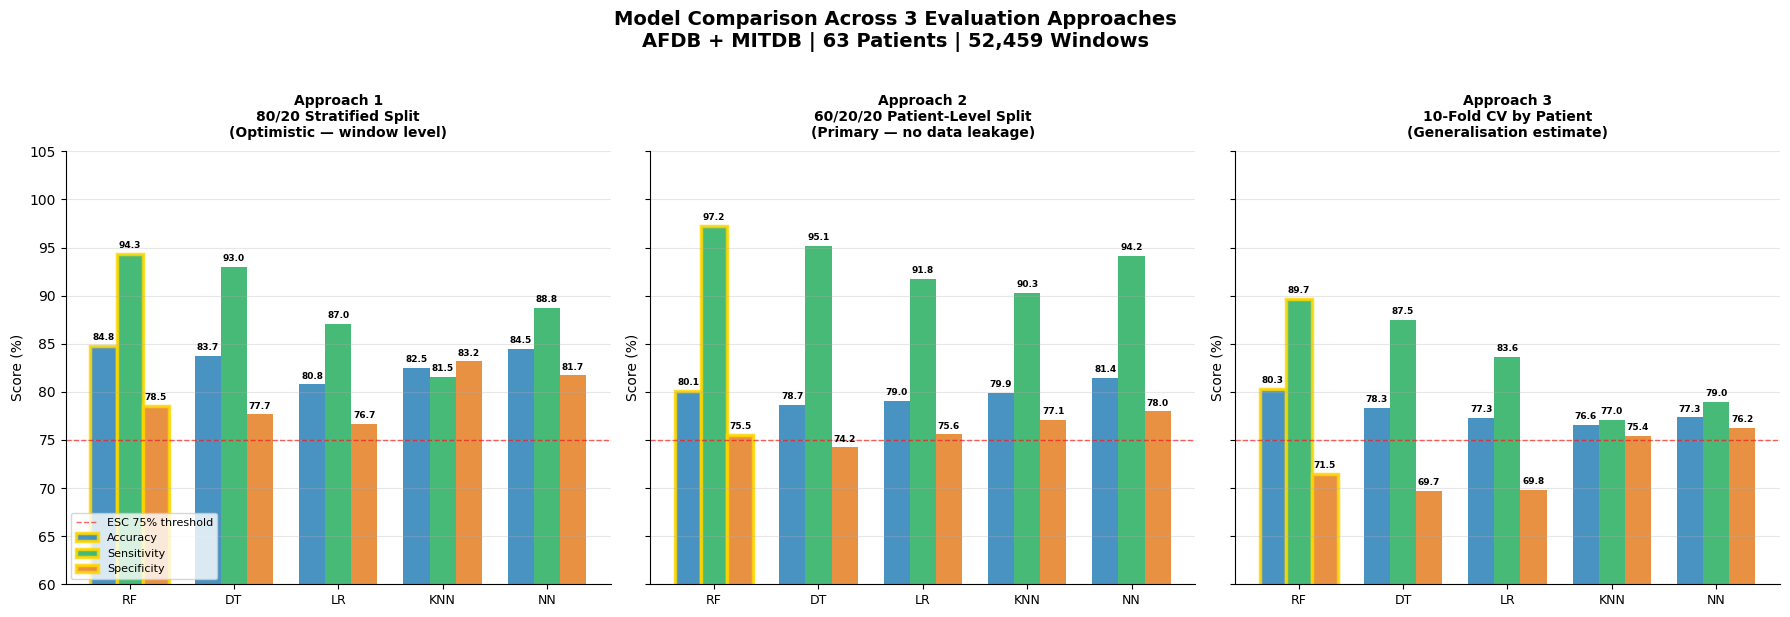

Saved: model_comparison_grouped.png


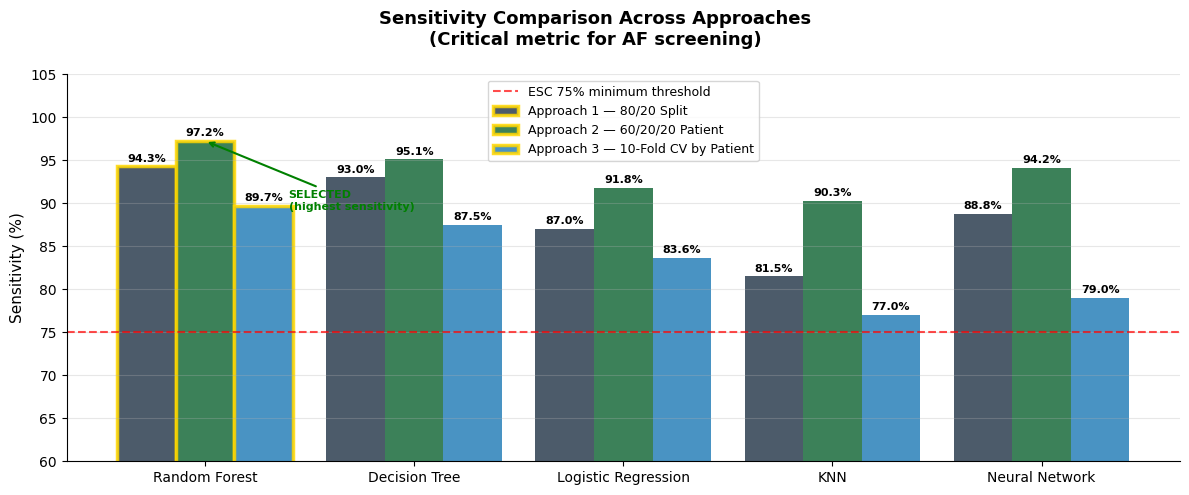

Saved: sensitivity_comparison.png


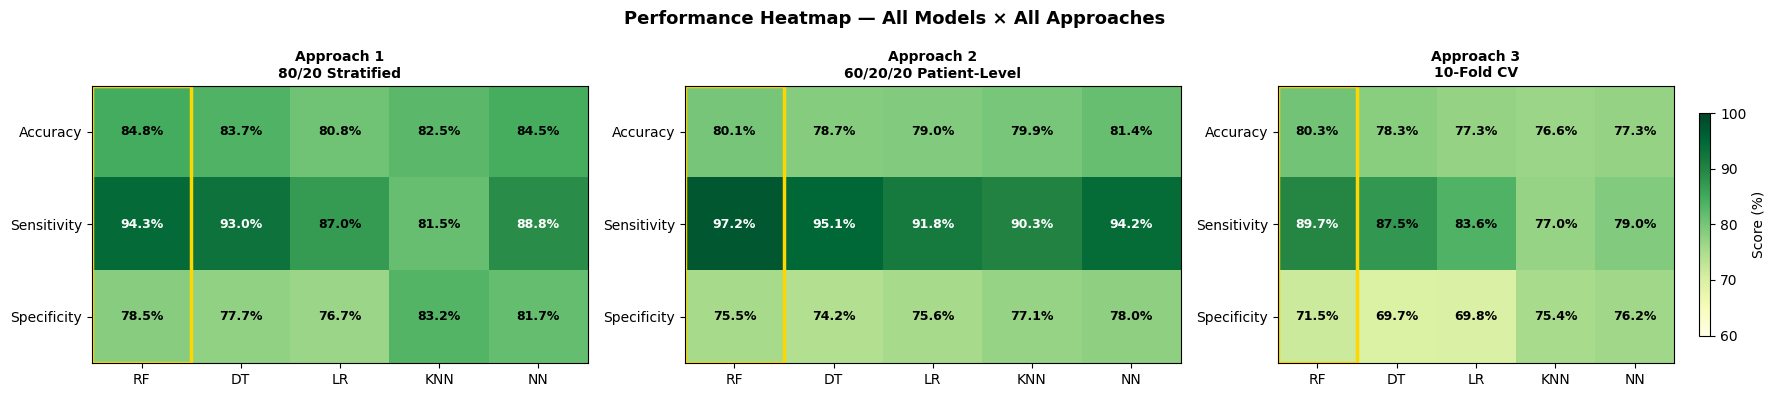

Saved: performance_heatmap.png

 All 3 figures saved to Drive.
  - model_comparison_grouped.png
  - sensitivity_comparison.png
  - performance_heatmap.png


In [8]:

# RESULTS VISUALIZATION

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Extract numeric values from results
def parse(val):
    return float(str(val).replace('%', ''))

models = [r['Model'] for r in results_8020]
metrics = ['Accuracy', 'Sensitivity', 'Specificity']
metric_labels = ['Accuracy', 'Sensitivity', 'Specificity']

# Build data arrays [models x metrics] for each approach
def build_matrix(results):
    return np.array([
        [parse(r['Accuracy']), parse(r['Sensitivity']), parse(r['Specificity'])]
        for r in results
    ])

# For approach 2 we use test_results (the honest evaluation)
data_a1 = build_matrix(results_8020)
data_a2 = build_matrix(test_results)
data_a3 = build_matrix(results_kfold)

# Color scheme
colors = {
    'Accuracy':    '#2980B9',
    'Sensitivity': '#27AE60',
    'Specificity': '#E67E22',
}
approach_colors = ['#2C3E50', '#1A6B3C', '#2980B9']

# FIGURE 1: Grouped bar chart — all models, all approaches
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Model Comparison Across 3 Evaluation Approaches\nAFDB + MITDB | 63 Patients | 52,459 Windows',
             fontsize=14, fontweight='bold', y=1.02)

approach_data   = [data_a1, data_a2, data_a3]
approach_titles = [
    'Approach 1\n80/20 Stratified Split\n(Optimistic — window level)',
    'Approach 2\n60/20/20 Patient-Level Split\n(Primary — no data leakage)',
    'Approach 3\n10-Fold CV by Patient\n(Generalisation estimate)'
]

x      = np.arange(len(models))
width  = 0.25
short_names = ['RF', 'DT', 'LR', 'KNN', 'NN']

for ax, data, title in zip(axes, approach_data, approach_titles):
    bars_acc  = ax.bar(x - width, data[:, 0], width, label='Accuracy',    color=colors['Accuracy'],    alpha=0.85)
    bars_sens = ax.bar(x,         data[:, 1], width, label='Sensitivity', color=colors['Sensitivity'], alpha=0.85)
    bars_spec = ax.bar(x + width, data[:, 2], width, label='Specificity', color=colors['Specificity'], alpha=0.85)

    # Highlight RF bars
    for bar in [bars_acc[0], bars_sens[0], bars_spec[0]]:
        bar.set_edgecolor('#FFD700')
        bar.set_linewidth(2.5)

    # Value labels on bars
    for bars in [bars_acc, bars_sens, bars_spec]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.4,
                    f'{h:.1f}', ha='center', va='bottom', fontsize=6.5, fontweight='bold')

    ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, fontsize=9)
    ax.set_ylim(60, 105)
    ax.set_ylabel('Score (%)', fontsize=10)
    ax.axhline(y=75, color='red', linestyle='--', linewidth=1, alpha=0.6, label='ESC 75% threshold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.savefig(SAVE_DIR + 'model_comparison_grouped.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison_grouped.png")

# FIGURE 2: Sensitivity focus — all models, all approaches
fig2, ax2 = plt.subplots(figsize=(12, 5))
fig2.suptitle('Sensitivity Comparison Across Approaches\n(Critical metric for AF screening)',
              fontsize=13, fontweight='bold')

x      = np.arange(len(models))
width  = 0.28

b1 = ax2.bar(x - width, data_a1[:, 1], width, label='Approach 1 — 80/20 Split',         color=approach_colors[0], alpha=0.85)
b2 = ax2.bar(x,         data_a2[:, 1], width, label='Approach 2 — 60/20/20 Patient',     color=approach_colors[1], alpha=0.85)
b3 = ax2.bar(x + width, data_a3[:, 1], width, label='Approach 3 — 10-Fold CV by Patient',color=approach_colors[2], alpha=0.85)

# Highlight RF
for bar in [b1[0], b2[0], b3[0]]:
    bar.set_edgecolor('#FFD700')
    bar.set_linewidth(2.5)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., h + 0.3,
                 f'{h:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=10)
ax2.set_ylim(60, 105)
ax2.set_ylabel('Sensitivity (%)', fontsize=11)
ax2.axhline(y=75, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='ESC 75% minimum threshold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Annotate RF as selected
ax2.annotate('SELECTED\n(highest sensitivity)', xy=(0, data_a2[0, 1]),
             xytext=(0.4, data_a2[0, 1] - 8),
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
             fontsize=8, color='green', fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_DIR + 'sensitivity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sensitivity_comparison.png")

# FIGURE 3: Summary heatmap table
fig3, axes3 = plt.subplots(1, 3, figsize=(18, 4))
fig3.suptitle('Performance Heatmap — All Models × All Approaches',
              fontsize=13, fontweight='bold')

approach_data_all   = [data_a1, data_a2, data_a3]
approach_titles_short = [
    'Approach 1\n80/20 Stratified',
    'Approach 2\n60/20/20 Patient-Level',
    'Approach 3\n10-Fold CV'
]

for ax, data, title in zip(axes3, approach_data_all, approach_titles_short):
    im = ax.imshow(data.T, cmap='YlGn', aspect='auto', vmin=60, vmax=100)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(short_names, fontsize=10)
    ax.set_yticks(range(3))
    ax.set_yticklabels(metric_labels, fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold')

    for i in range(len(models)):
        for j in range(3):
            ax.text(i, j, f'{data[i, j]:.1f}%',
                    ha='center', va='center', fontsize=9, fontweight='bold',
                    color='black' if data[i, j] < 88 else 'white')

    # Gold border around RF column
    rect = plt.Rectangle((-0.5, -0.5), 1, 3,
                          linewidth=2.5, edgecolor='#FFD700', facecolor='none')
    ax.add_patch(rect)

plt.colorbar(im, ax=axes3[-1], label='Score (%)', shrink=0.8)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'performance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: performance_heatmap.png")

print("\n All 3 figures saved to Drive.")
print("  - model_comparison_grouped.png")
print("  - sensitivity_comparison.png")
print("  - performance_heatmap.png")

CONFUSION MATRICE AND ROC CURVES

Generating confusion matrix and ROC plots...
Aggregating 10-fold CV predictions for Approach 3...
  Random Forest...
  Decision Tree...
  Logistic Regression...
  KNN...
  Neural Network...


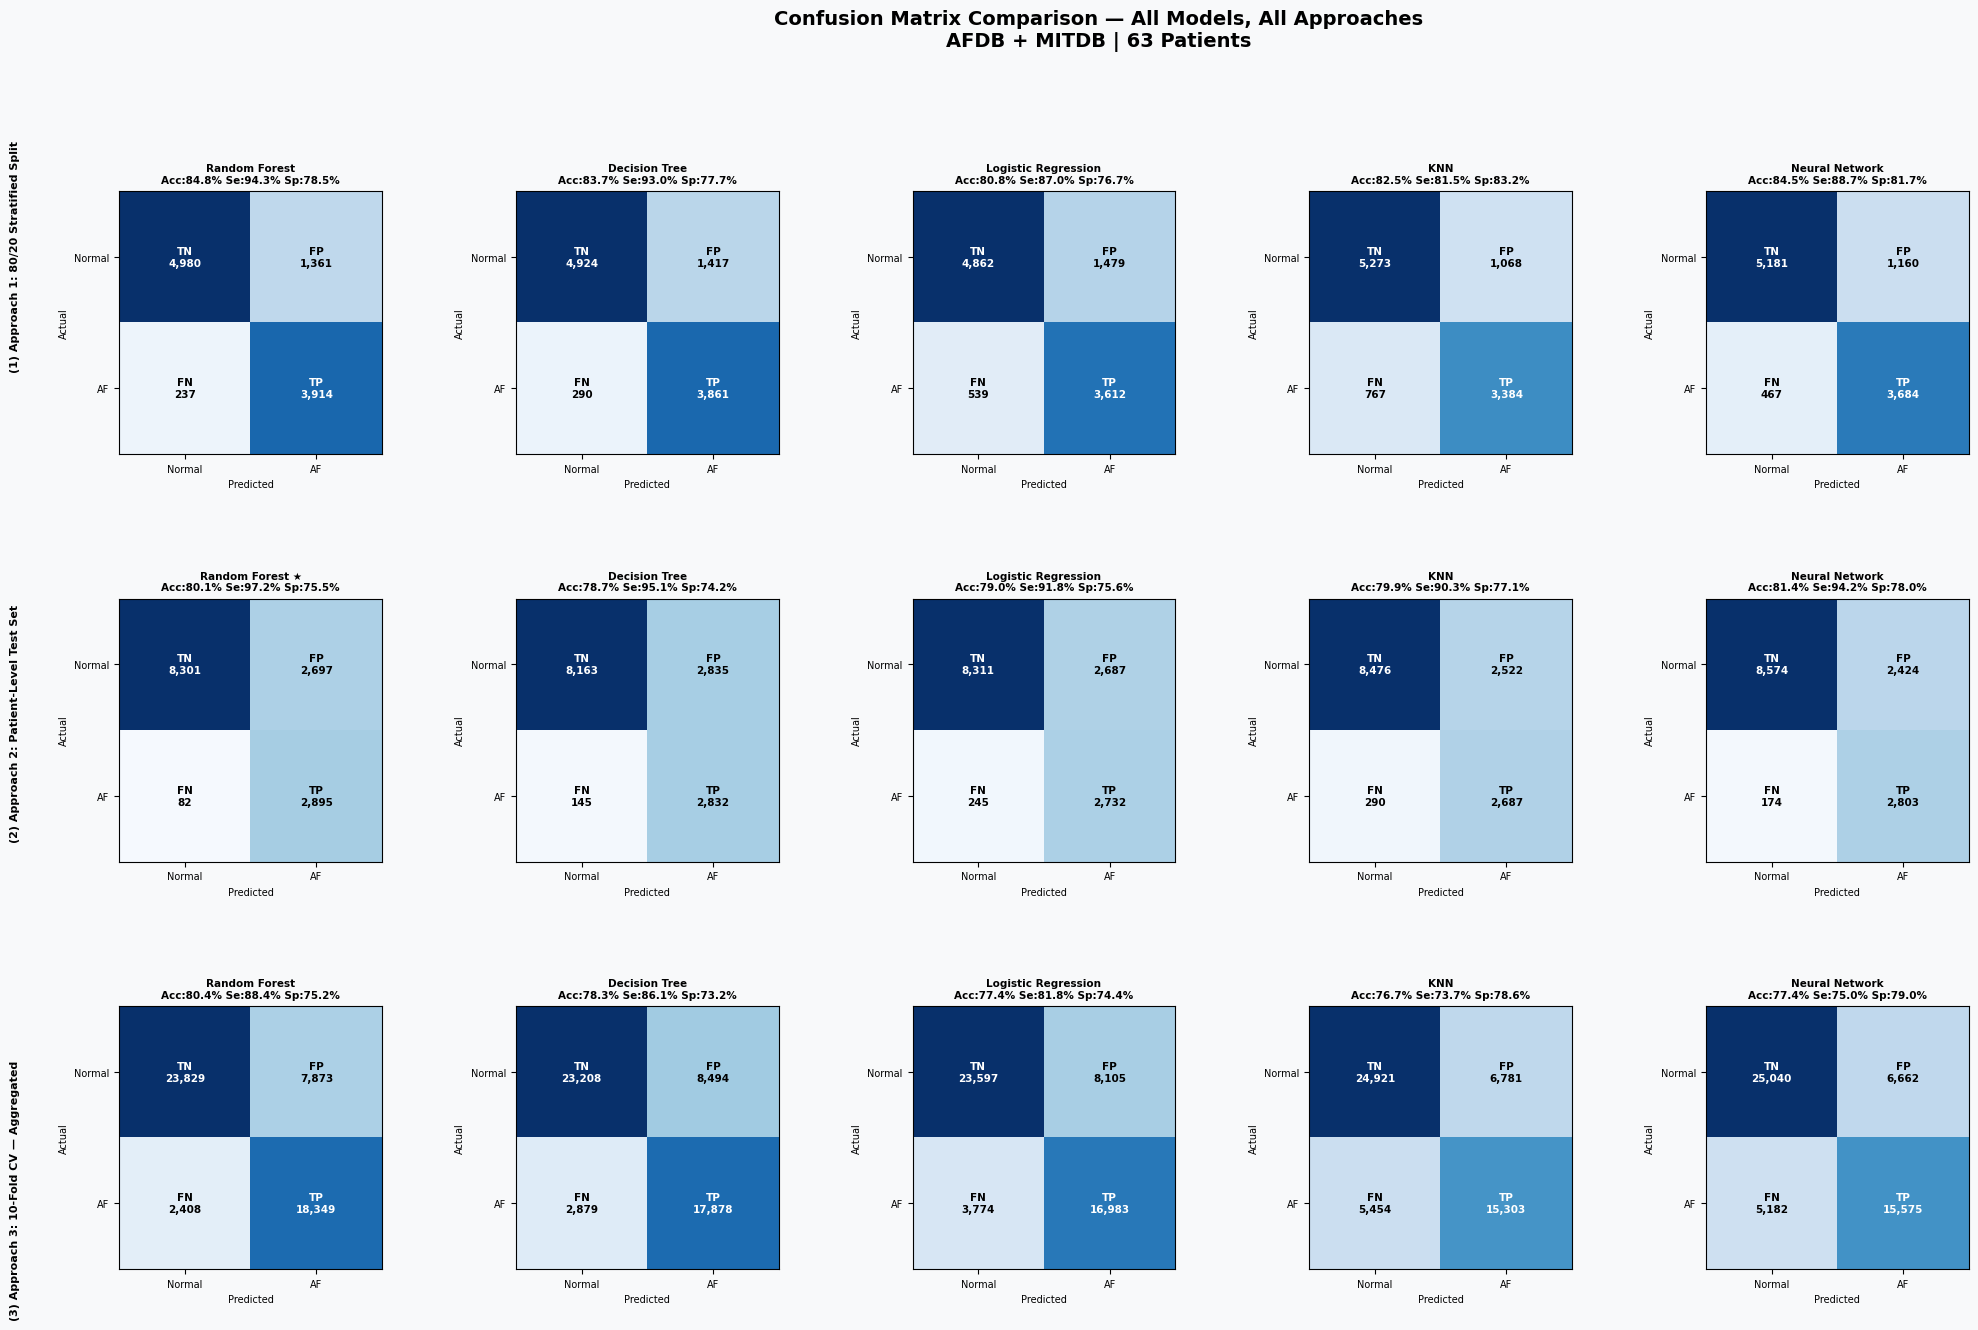

Saved: confusion_matrices.png


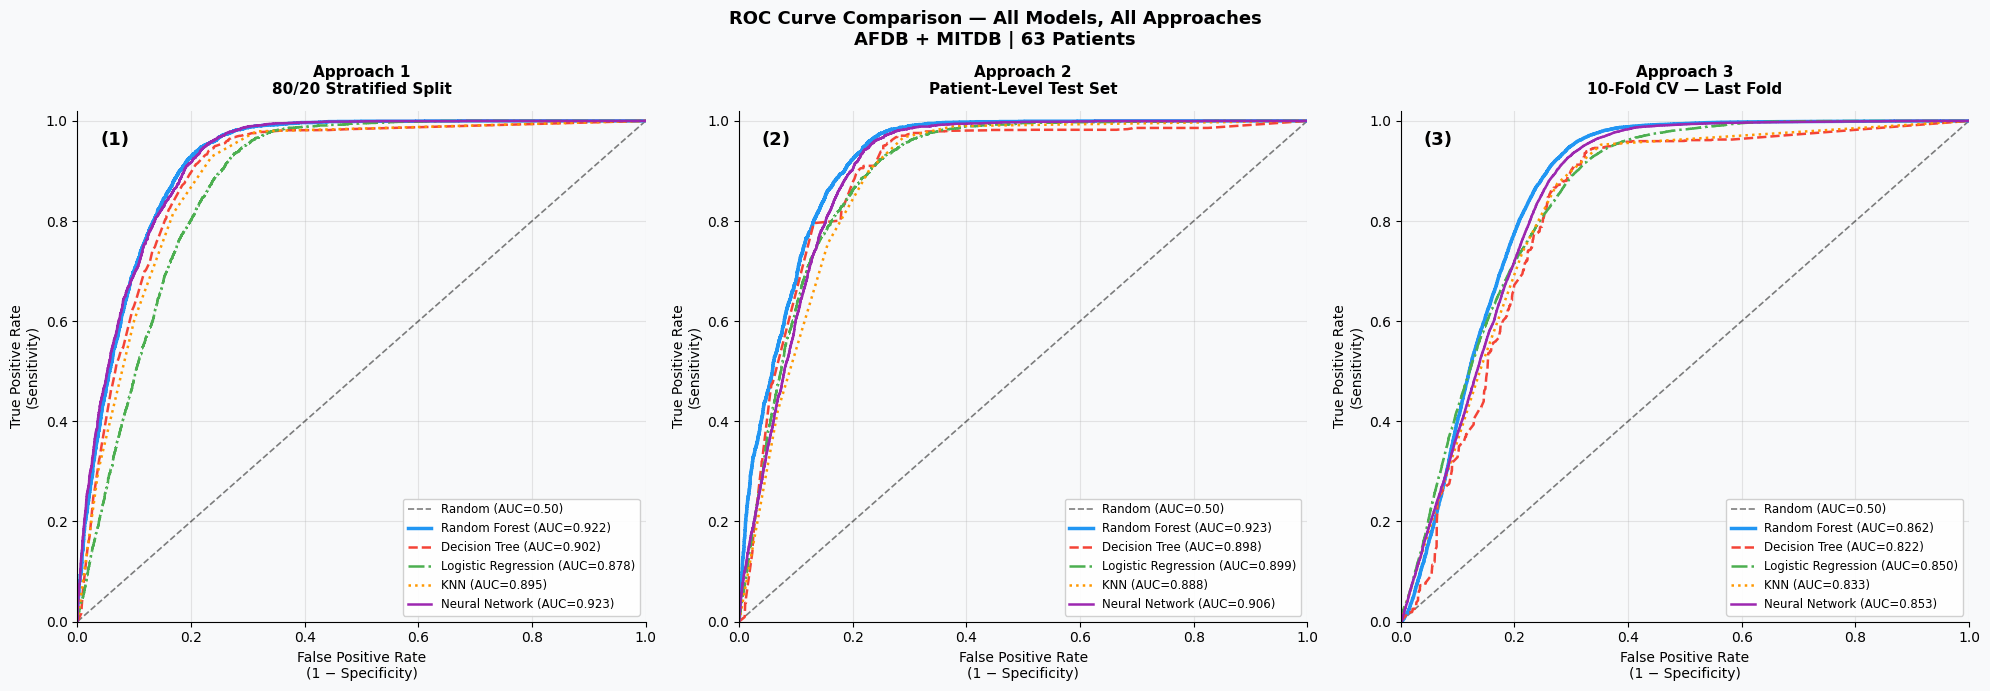

Saved: roc_curves.png

Cell 8 complete.


In [9]:

# CELL 8: CONFUSION MATRICES AND ROC CURVES

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import GroupKFold

print("Generating confusion matrix and ROC plots")

C_BG         = '#F8F9FA'
model_names  = list(trained_models.keys())
model_colors = {
    'Random Forest':       '#2196F3',
    'Decision Tree':       '#F44336',
    'Logistic Regression': '#4CAF50',
    'KNN':                 '#FF9800',
    'Neural Network':      '#9C27B0',
}
model_lines = {
    'Random Forest':       '-',
    'Decision Tree':       '--',
    'Logistic Regression': '-.',
    'KNN':                 ':',
    'Neural Network':      '-',
}

# Aggregate Approach 3 predictions
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

def get_models():
    return {
        'Random Forest': RandomForestClassifier(
            n_estimators=100, max_depth=10,
            min_samples_split=5, class_weight='balanced',
            random_state=42, n_jobs=-1),
        'Decision Tree': DecisionTreeClassifier(
            max_depth=10, class_weight='balanced',
            random_state=42),
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(
                max_iter=1000, class_weight='balanced',
                random_state=42))]),
        'KNN': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier(n_neighbors=5))]),
        'Neural Network': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', MLPClassifier(
                hidden_layer_sizes=(64, 32),
                max_iter=300, random_state=42))]),
    }

print("Aggregating 10-fold CV predictions for Approach 3")
preds_cv = {}
for name, model in get_models().items():
    print(f"  {name}")
    all_true, all_pred, all_prob = [], [], []
    for tr_idx, te_idx in GroupKFold(
            n_splits=10).split(X, y, groups):
        if len(np.unique(y[te_idx])) < 2: continue
        model.fit(X[tr_idx], y[tr_idx])
        all_true.extend(y[te_idx])
        all_pred.extend(model.predict(X[te_idx]))
        try:
            all_prob.extend(
                model.predict_proba(X[te_idx])[:, 1])
        except:
            all_prob.extend([0]*len(te_idx))
    preds_cv[name] = (
        np.array(all_true),
        np.array(all_pred),
        np.array(all_prob)
    )

# Prediction sets for each approach
approach_data = [
    ('Approach 1: 80/20 Stratified Split',
     {name: (y_te_w,
             trained_8020[name].predict(X_te_w),
             trained_8020[name].predict_proba(X_te_w)[:, 1])
      for name in model_names}),
    ('Approach 2: Patient-Level Test Set',
     {name: (y_test,
             trained_models[name].predict(X_test),
             trained_models[name].predict_proba(X_test)[:, 1])
      for name in model_names}),
    ('Approach 3: 10-Fold CV — Aggregated',
     {name: preds_cv[name] for name in model_names}),
]


# FIGURE 1: CONFUSION MATRICES (3 approaches × 5 models)

fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor(C_BG)
fig.suptitle(
    'Confusion Matrix Comparison — All Models, All Approaches\n'
    'AFDB + MITDB | 63 Patients',
    fontsize=14, fontweight='bold', y=1.01
)

outer = gridspec.GridSpec(3, 1, figure=fig, hspace=0.55)

for row_idx, (title, preds) in enumerate(approach_data):
    inner = gridspec.GridSpecFromSubplotSpec(
        1, len(model_names),
        subplot_spec=outer[row_idx], wspace=0.4)

    for col_idx, name in enumerate(model_names):
        ax = fig.add_subplot(inner[col_idx])
        ax.set_facecolor(C_BG)

        y_true_a, y_pred_a, _ = preds[name]
        if len(np.unique(y_true_a)) < 2:
            ax.text(0.5, 0.5, 'N/A',
                    ha='center', va='center',
                    transform=ax.transAxes)
            continue

        cm_p = confusion_matrix(y_true_a, y_pred_a)
        tn, fp, fn, tp = cm_p.ravel()
        sens = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
        acc  = (tn + tp) / cm_p.sum() * 100

        im = ax.imshow(cm_p, cmap='Blues',
                       vmin=0, vmax=cm_p.max())
        cell_labels = [['TN', 'FP'], ['FN', 'TP']]
        for i in range(2):
            for j in range(2):
                val   = cm_p[i, j]
                color = 'white' if val > cm_p.max()/2 \
                        else 'black'
                ax.text(j, i,
                        f'{cell_labels[i][j]}\n{val:,}',
                        ha='center', va='center',
                        fontsize=7.5,
                        fontweight='bold', color=color)

        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Normal', 'AF'], fontsize=7)
        ax.set_yticklabels(['Normal', 'AF'], fontsize=7)
        ax.set_xlabel('Predicted', fontsize=7)
        ax.set_ylabel('Actual', fontsize=7)

        star = ' ★' if name == best_name and row_idx == 1 \
               else ''
        ax.set_title(
            f'{name}{star}\n'
            f'Acc:{acc:.1f}% '
            f'Se:{sens:.1f}% '
            f'Sp:{spec:.1f}%',
            fontsize=7.5, fontweight='bold'
        )

    fig.text(
        0.005,
        1 - (row_idx + 0.5) / 3,
        f'({row_idx+1}) {title}',
        va='center', ha='left',
        fontsize=8, fontweight='bold', rotation=90
    )

plt.subplots_adjust(left=0.05)
plt.savefig(SAVE_DIR + 'confusion_matrices.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: confusion_matrices.png")


# FIGURE 2: ROC CURVES (3 approaches)

# Get last fold indices for Approach 3 ROC
splits_roc   = list(GroupKFold(
    n_splits=10).split(X, y, groups))
tr_last, te_last = splits_roc[-1]

fig2, axes = plt.subplots(1, 3, figsize=(20, 7))
fig2.patch.set_facecolor(C_BG)
fig2.suptitle(
    'ROC Curve Comparison — All Models, All Approaches\n'
    'AFDB + MITDB | 63 Patients',
    fontsize=13, fontweight='bold'
)

roc_sets = [
    ('Approach 1\n80/20 Stratified Split',
     approach_data[0][1]),
    ('Approach 2\nPatient-Level Test Set',
     approach_data[1][1]),
    ('Approach 3\n10-Fold CV — Last Fold',
     {name: preds_cv[name] for name in model_names}),
]

for ax_idx, (title, preds) in enumerate(roc_sets):
    ax = axes[ax_idx]
    ax.set_facecolor(C_BG)
    ax.plot([0, 1], [0, 1], 'k--',
            linewidth=1.2, alpha=0.5,
            label='Random (AUC=0.50)')

    for name in model_names:
        y_true_r, _, y_prob_r = preds[name]
        if len(np.unique(y_true_r)) < 2: continue
        try:
            fpr, tpr, _ = roc_curve(y_true_r, y_prob_r)
            auc         = roc_auc_score(y_true_r, y_prob_r)
            lw = 2.5 if name == best_name else 1.8
            ax.plot(fpr, tpr,
                    color=model_colors[name],
                    linestyle=model_lines[name],
                    linewidth=lw,
                    label=f'{name} (AUC={auc:.3f})')
        except:
            continue

    ax.set_xlabel('False Positive Rate\n(1 − Specificity)',
                  fontsize=10)
    ax.set_ylabel('True Positive Rate\n(Sensitivity)',
                  fontsize=10)
    ax.set_title(title, fontsize=11,
                 fontweight='bold', pad=12)
    ax.legend(loc='lower right', fontsize=8.5,
              framealpha=0.9)
    ax.grid(alpha=0.3)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.text(0.04, 0.96, f'({ax_idx+1})',
            transform=ax.transAxes,
            fontsize=13, fontweight='bold', va='top')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'roc_curves.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: roc_curves.png")
print("\nCell 8 complete.")

In an attempt to reduce the false positives

RF THRESHOLD SWEEP (Approach 2: 60/20/20 patient split)

  Default threshold (0.50):
    Sensitivity : 97.2%
    Specificity : 75.5%
    NPV         : 99.0%
    FP count    : 2,697
    FN count    : 82

  Selected threshold (0.59):
    Sensitivity : 95.2%
    Specificity : 77.6%
    NPV         : 98.3%
    FP count    : 2,461  (was 2,697)
    FN count    : 144  (was 82)
    FP reduction: 236 fewer false positives


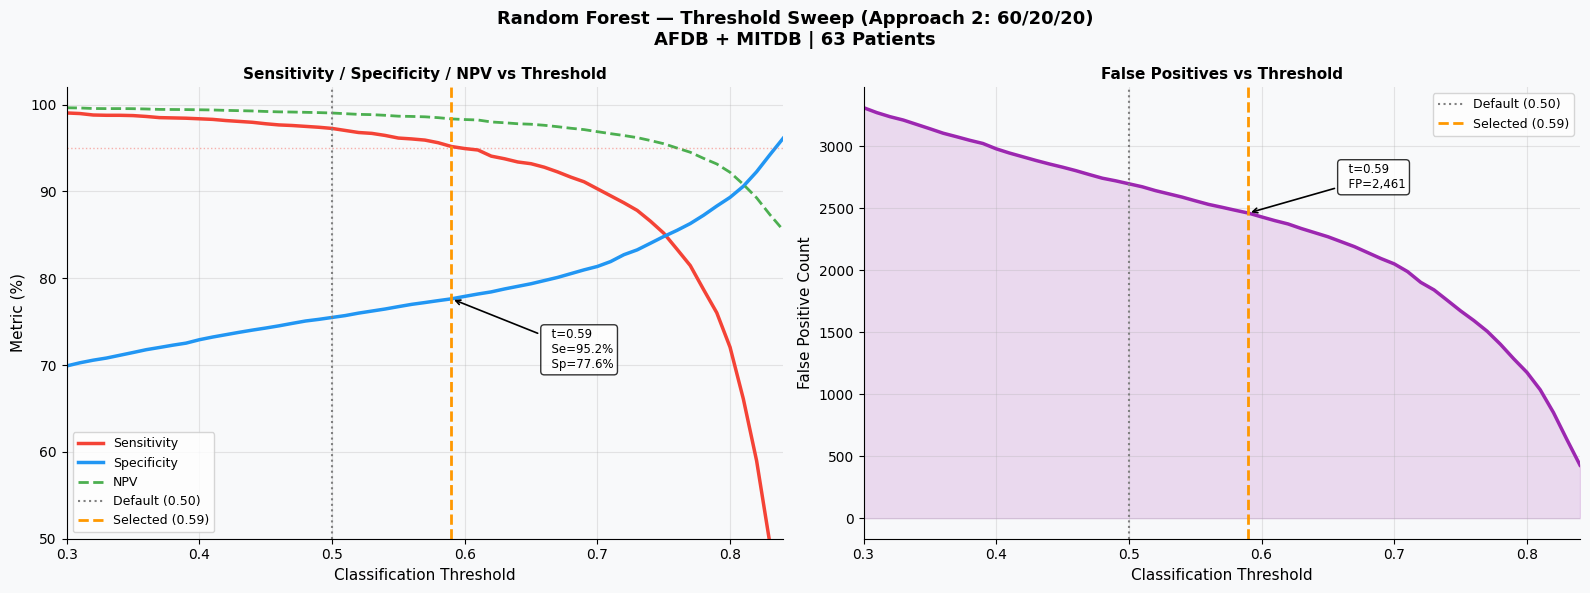

Saved: rf_threshold_sweep.png


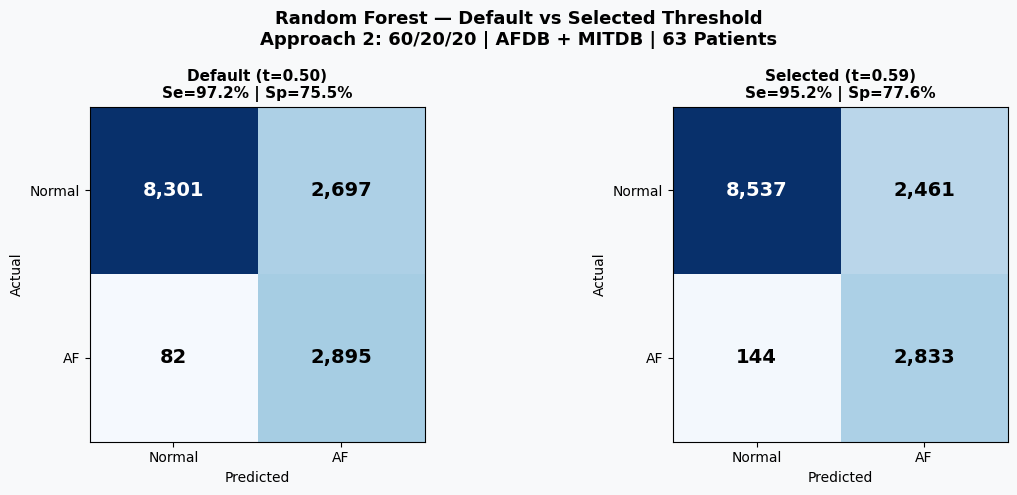

Saved: rf_threshold_cm_comparison.png

RECOMMENDATION: Use threshold = 0.59
  Retains sensitivity ≥ 95% (screening requirement)
  Reduces false positives from 2,697 → 2,461


In [11]:

# RF THRESHOLD SWEEP — Sensitivity vs Specificity

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix, roc_auc_score


print("RF THRESHOLD SWEEP (Approach 2: 60/20/20 patient split)")


C_BG   = '#F8F9FA'
C_SENS = '#F44336'   # red   — sensitivity
C_SPEC = '#2196F3'   # blue  — specificity
C_NPV  = '#4CAF50'   # green — NPV
C_SEL  = '#FF9800'   # orange — selected threshold marker

rf   = trained_models['Random Forest']
prob = rf.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.30, 0.85, 0.01)

records = []
for t in thresholds:
    pred = (prob >= t).astype(int)
    cm   = confusion_matrix(y_test, pred)
    if cm.shape != (2, 2):
        continue
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
    npv  = tn / (tn + fn) * 100 if (tn + fn) > 0 else 0
    acc  = (tp + tn) / (tp + tn + fp + fn) * 100
    records.append(dict(t=t, sens=sens, spec=spec,
                        npv=npv, acc=acc, fp=fp, fn=fn,
                        tp=tp, tn=tn))

# Find best threshold: sens >= 95%, maximise specificity
candidates = [r for r in records if r['sens'] >= 95.0]
if candidates:
    best = max(candidates, key=lambda r: r['spec'])
else:
    # relax to 90% if nothing meets 95%
    candidates = [r for r in records if r['sens'] >= 90.0]
    best = max(candidates, key=lambda r: r['spec'])

print(f"\n  Default threshold (0.50):")
default = next(r for r in records if abs(r['t'] - 0.50) < 0.006)
print(f"    Sensitivity : {default['sens']:.1f}%")
print(f"    Specificity : {default['spec']:.1f}%")
print(f"    NPV         : {default['npv']:.1f}%")
print(f"    FP count    : {default['fp']:,}")
print(f"    FN count    : {default['fn']:,}")

print(f"\n  Selected threshold ({best['t']:.2f}):")
print(f"    Sensitivity : {best['sens']:.1f}%")
print(f"    Specificity : {best['spec']:.1f}%")
print(f"    NPV         : {best['npv']:.1f}%")
print(f"    FP count    : {best['fp']:,}  (was {default['fp']:,})")
print(f"    FN count    : {best['fn']:,}  (was {default['fn']:,})")
print(f"    FP reduction: {default['fp'] - best['fp']:,} fewer false positives")

# FIGURE 1: Sweep curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(C_BG)
fig.suptitle(
    'Random Forest — Threshold Sweep (Approach 2: 60/20/20)\n'
    'AFDB + MITDB | 63 Patients',
    fontsize=13, fontweight='bold'
)

ts    = [r['t']    for r in records]
senss = [r['sens'] for r in records]
specs = [r['spec'] for r in records]
npvs  = [r['npv']  for r in records]
fps   = [r['fp']   for r in records]

# Panel 1: Sens / Spec / NPV vs threshold
ax = axes[0]
ax.set_facecolor(C_BG)
ax.plot(ts, senss, color=C_SENS, lw=2.5, label='Sensitivity')
ax.plot(ts, specs, color=C_SPEC, lw=2.5, label='Specificity')
ax.plot(ts, npvs,  color=C_NPV,  lw=2.0, label='NPV', linestyle='--')
ax.axvline(0.50,      color='grey',  lw=1.5, linestyle=':',  label='Default (0.50)')
ax.axvline(best['t'], color=C_SEL,   lw=2.0, linestyle='--', label=f"Selected ({best['t']:.2f})")
ax.axhline(95.0, color=C_SENS, lw=1.0, linestyle=':', alpha=0.4)
ax.set_xlabel('Classification Threshold', fontsize=11)
ax.set_ylabel('Metric (%)', fontsize=11)
ax.set_title('Sensitivity / Specificity / NPV vs Threshold', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0.30, 0.84)
ax.set_ylim(50, 102)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate selected point
ax.annotate(
    f"  t={best['t']:.2f}\n  Se={best['sens']:.1f}%\n  Sp={best['spec']:.1f}%",
    xy=(best['t'], best['spec']),
    xytext=(best['t'] + 0.07, best['spec'] - 8),
    fontsize=8.5,
    arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
)

# Panel 2: FP count vs threshold
ax2 = axes[1]
ax2.set_facecolor(C_BG)
ax2.plot(ts, fps, color='#9C27B0', lw=2.5)
ax2.axvline(0.50,      color='grey', lw=1.5, linestyle=':',  label='Default (0.50)')
ax2.axvline(best['t'], color=C_SEL,  lw=2.0, linestyle='--', label=f"Selected ({best['t']:.2f})")
ax2.fill_between(ts, fps, alpha=0.15, color='#9C27B0')
ax2.set_xlabel('Classification Threshold', fontsize=11)
ax2.set_ylabel('False Positive Count', fontsize=11)
ax2.set_title('False Positives vs Threshold', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xlim(0.30, 0.84)
ax2.grid(alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Annotate FP at selected threshold
ax2.annotate(
    f"  t={best['t']:.2f}\n  FP={best['fp']:,}",
    xy=(best['t'], best['fp']),
    xytext=(best['t'] + 0.07, best['fp'] + 200),
    fontsize=8.5,
    arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'rf_threshold_sweep.png', dpi=150,
            bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: rf_threshold_sweep.png")

# FIGURE 2: Confusion matrix at selected threshold
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.patch.set_facecolor(C_BG)
fig2.suptitle(
    f'Random Forest — Default vs Selected Threshold\n'
    f'Approach 2: 60/20/20 | AFDB + MITDB | 63 Patients',
    fontsize=13, fontweight='bold'
)

for ax, r, label in zip(
    axes2,
    [default, best],
    [f"Default (t=0.50)\nSe={default['sens']:.1f}% | Sp={default['spec']:.1f}%",
     f"Selected (t={best['t']:.2f})\nSe={best['sens']:.1f}% | Sp={best['spec']:.1f}%"]
):
    cm_vals = np.array([[r['tn'], r['fp']], [r['fn'], r['tp']]])
    im = ax.imshow(cm_vals, interpolation='nearest',
                   cmap='Blues', vmin=0, vmax=cm_vals.max())
    ax.set_facecolor(C_BG)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Normal', 'AF'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Normal', 'AF'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm_vals[i, j]:,}',
                    ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm_vals[i, j] > cm_vals.max()*0.5 else 'black')

plt.tight_layout()
plt.savefig(SAVE_DIR + 'rf_threshold_cm_comparison.png', dpi=150,
            bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: rf_threshold_cm_comparison.png")


print(f"RECOMMENDATION: Use threshold = {best['t']:.2f}")
print(f"  Retains sensitivity ≥ 95% (screening requirement)")
print(f"  Reduces false positives from {default['fp']:,}  {best['fp']:,}")


RF GRID SEARCH — Finding better Se/Sp balance
  Testing 144 configurations...

  [20/144] done...
  [40/144] done...
  [60/144] done...
  [80/144] done...
  [100/144] done...
  [120/144] done...
  [140/144] done...

TOP CONFIGS — Sensitivity ≥ 95%, ranked by Specificity
 n_trees  max_depth class_weight  min_leaf  sens  spec   npv   fp  fn
       7         10     balanced         5 96.78 75.16 98.85 2732  96
     100         10     balanced         1 97.41 74.86 99.07 2765  77
      50         10     balanced         1 97.31 74.75 99.04 2777  80
       7         10     balanced         1 96.67 74.70 98.81 2783  99
      15         10     balanced         1 96.91 74.61 98.89 2792  92
      15         10     balanced         5 97.45 74.60 99.08 2793  76
     100         10     balanced         5 97.38 74.54 99.06 2800  78
      50          7     balanced         1 97.58 74.50 99.13 2805  72
      50         10     balanced         5 97.45 74.50 99.08 2805  76
     100         10     balan

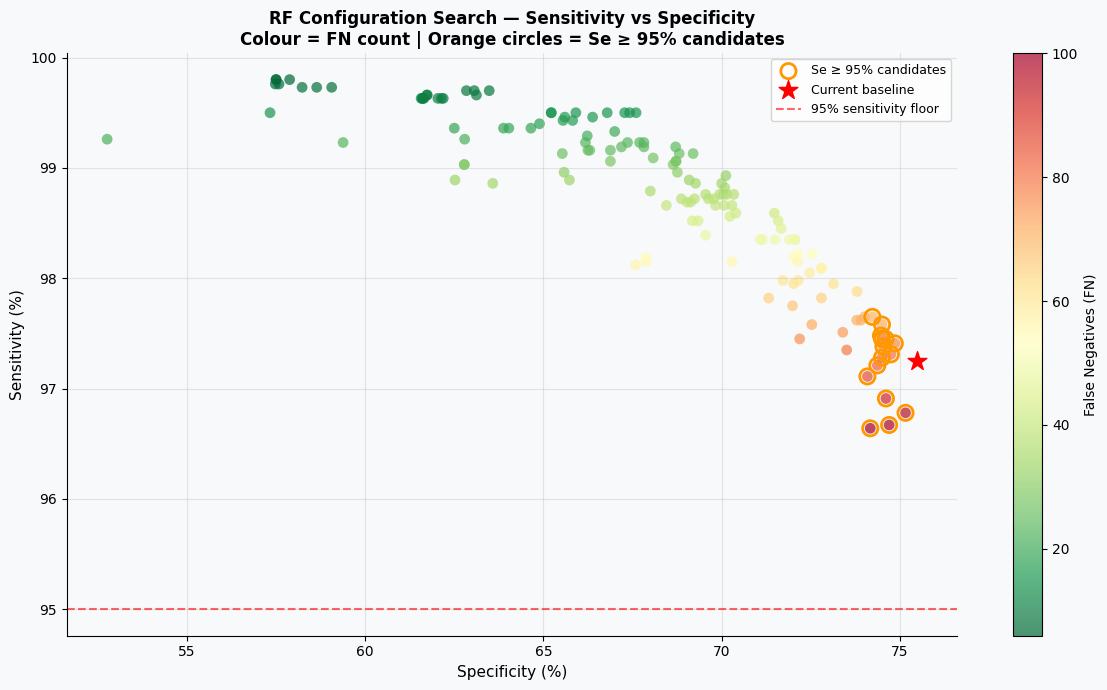

Saved: rf_grid_search.png


In [12]:

# RF CONFIGURATION GRID SEARCH

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix


print("RF GRID SEARCH — Finding better Se/Sp balance")


C_BG = '#F8F9FA'

# Grid: things that actually affect FP rate
n_trees_opts    = [7, 15, 50, 100]
max_depth_opts  = [5, 7, 10]
class_weight_opts = [
    'balanced',
    {0: 1, 1: 2},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
]
min_samples_leaf_opts = [1, 5, 10]

results = []
total = (len(n_trees_opts) * len(max_depth_opts) *
         len(class_weight_opts) * len(min_samples_leaf_opts))
print(f"  Testing {total} configurations\n")

count = 0
for n_trees in n_trees_opts:
    for max_d in max_depth_opts:
        for cw in class_weight_opts:
            for msl in min_samples_leaf_opts:
                count += 1
                rf = RandomForestClassifier(
                    n_estimators=n_trees,
                    max_depth=max_d,
                    class_weight=cw,
                    min_samples_leaf=msl,
                    random_state=42,
                    n_jobs=-1
                )
                rf.fit(X_train, y_train)
                pred = rf.predict(X_test)
                cm   = confusion_matrix(y_test, pred)
                if cm.shape != (2,2): continue
                tn, fp, fn, tp = cm.ravel()
                sens = tp/(tp+fn)*100 if (tp+fn)>0 else 0
                spec = tn/(tn+fp)*100 if (tn+fp)>0 else 0
                npv  = tn/(tn+fn)*100 if (tn+fn)>0 else 0
                acc  = (tp+tn)/(tp+tn+fp+fn)*100

                cw_label = (cw if isinstance(cw, str)
                            else f"{{0:{cw[0]},1:{cw[1]}}}")
                results.append(dict(
                    n_trees=n_trees, max_depth=max_d,
                    class_weight=cw_label,
                    min_leaf=msl,
                    sens=round(sens,2), spec=round(spec,2),
                    npv=round(npv,2),  acc=round(acc,2),
                    fp=fp, fn=fn, tp=tp, tn=tn
                ))
                if count % 20 == 0:
                    print(f"  [{count}/{total}] done")

df_res = pd.DataFrame(results)

# Show top candidates: sens >= 95%, ranked by spec

print("TOP CONFIGS — Sensitivity ≥ 95%, ranked by Specificity")

top = (df_res[df_res['sens'] >= 95.0]
       .sort_values('spec', ascending=False)
       .head(15))
print(top[['n_trees','max_depth','class_weight','min_leaf',
           'sens','spec','npv','fp','fn']].to_string(index=False))

# Also show best Se/Sp balance (Youden's J)
df_res['youden'] = df_res['sens'] + df_res['spec'] - 100

print("TOP CONFIGS — Best Youden's J (sens + spec - 100)")

top_j = df_res.sort_values('youden', ascending=False).head(10)
print(top_j[['n_trees','max_depth','class_weight','min_leaf',
             'sens','spec','npv','fp','fn','youden']].to_string(index=False))

# Current baseline for reference
baseline = df_res[
    (df_res['n_trees']==100) &
    (df_res['max_depth']==10) &
    (df_res['class_weight']=='balanced') &
    (df_res['min_leaf']==1)
]
if not baseline.empty:
    b = baseline.iloc[0]
    print(f"\n  Baseline (current config): "
          f"Se={b['sens']}% | Sp={b['spec']}% | "
          f"FP={b['fp']} | FN={b['fn']}")

# PLOT: Scatter of all configs
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(C_BG)
ax.set_facecolor(C_BG)

sc = ax.scatter(
    df_res['spec'], df_res['sens'],
    c=df_res['fn'], cmap='RdYlGn_r',
    s=60, alpha=0.7, edgecolors='none'
)
plt.colorbar(sc, ax=ax, label='False Negatives (FN)')

# Highlight top candidates
if not top.empty:
    ax.scatter(top['spec'], top['sens'],
               s=120, facecolors='none',
               edgecolors='#FF9800', linewidths=2,
               label='Se ≥ 95% candidates', zorder=5)

# Mark baseline
ax.scatter(default['spec'], default['sens'],
           s=200, marker='*', color='red',
           label=f"Current baseline", zorder=6)

ax.axhline(95, color='red', lw=1.5, linestyle='--',
           alpha=0.6, label='95% sensitivity floor')
ax.set_xlabel('Specificity (%)', fontsize=11)
ax.set_ylabel('Sensitivity (%)', fontsize=11)
ax.set_title(
    'RF Configuration Search — Sensitivity vs Specificity\n'
    'Colour = FN count | Orange circles = Se ≥ 95% candidates',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'rf_grid_search.png', dpi=150,
            bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: rf_grid_search.png")

In [13]:
# What did non-balanced weights actually produce?
print("NON-BALANCED CLASS WEIGHTS — full results")

non_bal = df_res[df_res['class_weight'] != 'balanced'].sort_values('youden', ascending=False)
print(non_bal[['n_trees','max_depth','class_weight','min_leaf',
               'sens','spec','npv','fp','fn','youden']].to_string(index=False))

NON-BALANCED CLASS WEIGHTS — full results
 n_trees  max_depth class_weight  min_leaf  sens  spec   npv   fp  fn  youden
     100         10    {0:1,1:2}         5 98.35 72.05 99.39 3074  49   70.40
     100         10    {0:1,1:2}         1 98.22 72.14 99.34 3064  53   70.36
      50         10    {0:1,1:2}         5 98.19 72.02 99.32 3077  54   70.21
      50         10    {0:1,1:2}         1 97.98 72.15 99.25 3063  60   70.13
      50         10    {0:1,1:2}        10 98.45 71.67 99.42 3116  46   70.12
     100         10    {0:1,1:2}        10 98.52 71.59 99.44 3124  44   70.11
      15         10    {0:1,1:2}         5 97.95 72.02 99.24 3077  61   69.97
      15         10    {0:1,1:2}        10 98.35 71.50 99.38 3134  49   69.85
       7         10    {0:1,1:2}         1 97.75 71.99 99.16 3081  67   69.74
       7         10    {0:1,1:2}         5 97.98 71.72 99.25 3110  60   69.70
      15         10    {0:1,1:2}         1 97.45 72.19 99.05 3059  76   69.64
       7         10   

FEATURE IMPORTANCE, SIZE VRS PERFORMANCE

FEATURE IMPORTANCE — RANDOM FOREST

Feature importances (Mean Decrease in Impurity):

  Rank   Feature      Importance Bar
  -------------------------------------------------------
  1      mean_rr          44.16%  ██████████████████████████
  2      sdsd             14.15%  ████████
  3      pRR20            13.51%  ████████
  4      pRR30             9.57%  █████
  5      pRR50             7.62%  ████
  6      tpr               6.10%  ███
  7      pRR6_25           4.90%  ██

Top feature   : mean_rr (44.16%)
Bottom feature: pRR6_25 (4.90%)

SIZE VS PERFORMANCE TRADE-OFF (ESP32 deployment)

Evaluating Random Forest across candidate
configurations within the 30 KB flash budget...

  100 trees depth 10 | Sens: 97.25% | Spec: 75.48% | NPV: 99.02% | ~4175.3 KB ✗ TOO LARGE
   10 trees depth 5 | Sens: 97.14% | Spec: 74.82% | NPV: 98.98% | ~30.7 KB ✗ TOO LARGE
    7 trees depth 5 | Sens: 97.72% | Spec: 73.74% | NPV: 99.17% | ~21.7 KB ✓ FITS
    5 trees depth 5 | Sens: 97.11% | Spec: 73.57% |

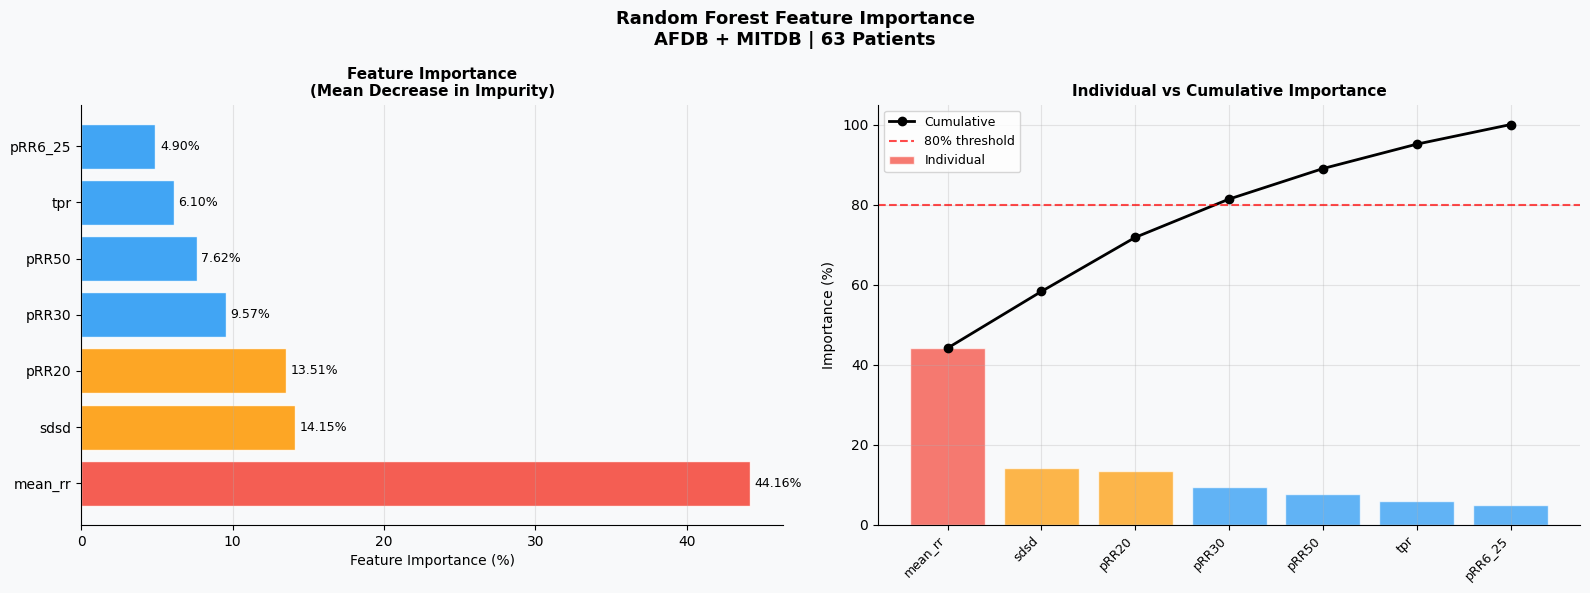


Saved: feature_importance.png


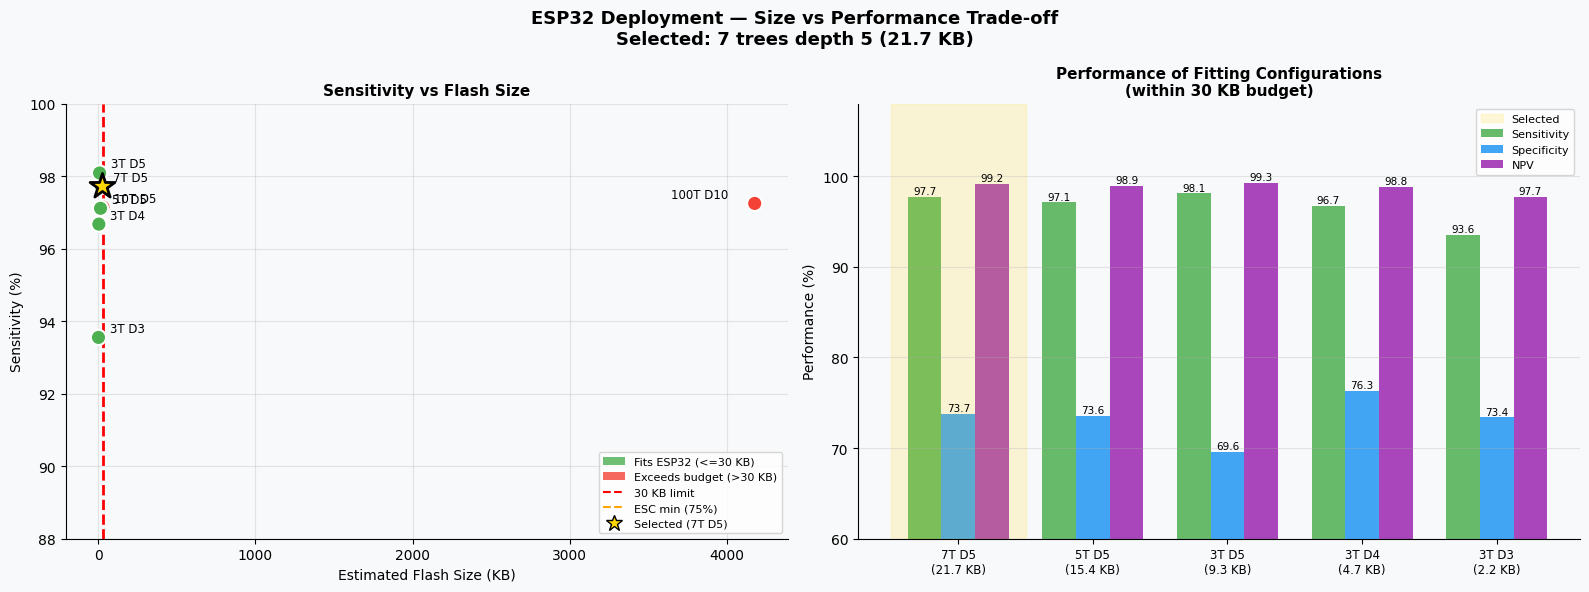

Saved: size_vs_performance.png


In [10]:

# FEATURE IMPORTANCE + SIZE VS PERFORMANCE

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from matplotlib.patches import Patch


print("FEATURE IMPORTANCE — RANDOM FOREST")


C_BG = '#F8F9FA'

# Extract RF feature importance
rf_model = trained_models['Random Forest']
rf_clf   = rf_model.named_steps['clf'] \
           if hasattr(rf_model, 'named_steps') else rf_model

importances = rf_clf.feature_importances_
importance_pairs = sorted(
    zip(FEATURE_NAMES, importances),
    key=lambda x: -x[1]
)

print("\nFeature importances (Mean Decrease in Impurity):")
print(f"\n  {'Rank':<6} {'Feature':<12} {'Importance':>10} {'Bar'}")
print(f"  {'-'*55}")
for rank, (feat, imp) in enumerate(importance_pairs, 1):
    bar = '█' * int(imp * 60)
    print(f"  {rank:<6} {feat:<12} {imp*100:>9.2f}%  {bar}")

print(f"\nTop feature   : {importance_pairs[0][0]} "
      f"({importance_pairs[0][1]*100:.2f}%)")
print(f"Bottom feature: {importance_pairs[-1][0]} "
      f"({importance_pairs[-1][1]*100:.2f}%)")

# Size vs performance trade-off

print("SIZE VS PERFORMANCE TRADE-OFF (ESP32 deployment)")

print("\nEvaluating Random Forest across candidate")
print("configurations within the 30 KB flash budget\n")

# Empirically measured flash sizes from actual ESP32
# header file generation and deployment testing
size_lookup = {
    (100, 10): 4175.3,
    (10,   5):   30.7,
    (7,    5):   21.7,
    (5,    5):   15.4,
    (3,    5):    9.3,
    (3,    4):    4.7,
    (3,    3):    2.2,
}

def evaluate_rf(n_trees, max_d, X_tr, y_tr, X_te, y_te):
    rf = RandomForestClassifier(
        n_estimators=n_trees, max_depth=max_d,
        min_samples_split=5, class_weight='balanced',
        random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)
    acc  = accuracy_score(y_te, y_pred) * 100
    cm   = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
    npv  = tn / (tn + fn) * 100 if (tn + fn) > 0 else 0
    try:
        auc = round(roc_auc_score(
            y_te, rf.predict_proba(X_te)[:, 1]), 4)
    except:
        auc = None
    est_kb = size_lookup.get((n_trees, max_d), 999.9)
    return acc, sens, spec, npv, auc, est_kb, rf

configs      = [(100,10),(10,5),(7,5),(5,5),(3,5),(3,4),(3,3)]
size_results = []

for n_trees, max_d in configs:
    acc, sens, spec, npv, auc, est_kb, rf_tmp = evaluate_rf(
        n_trees, max_d,
        X_trainval, y_trainval,
        X_test,     y_test)
    fits = est_kb <= 30.0
    size_results.append({
        'Trees':       n_trees,
        'Depth':       max_d,
        'Sensitivity': sens,
        'Specificity': spec,
        'Accuracy':    acc,
        'NPV':         npv,
        'AUC':         auc,
        'Est_KB':      est_kb,
        'Fits':        fits,
        '_model':      rf_tmp
    })
    marker = ' ✓ FITS' if fits else ' ✗ TOO LARGE'
    print(f"  {n_trees:>3} trees depth {max_d} | "
          f"Sens: {sens:.2f}% | "
          f"Spec: {spec:.2f}% | "
          f"NPV: {npv:.2f}% | "
          f"~{est_kb:.1f} KB{marker}")

# Print full table
print(f"\nFull results table:")
display_cols = ['Trees','Depth','Sensitivity',
                'Specificity','Accuracy','NPV',
                'AUC','Est_KB','Fits']
df_size = pd.DataFrame(size_results)[display_cols].copy()
df_size['Sensitivity'] = df_size['Sensitivity'].apply(
    lambda x: f"{x:.2f}%")
df_size['Specificity'] = df_size['Specificity'].apply(
    lambda x: f"{x:.2f}%")
df_size['Accuracy']    = df_size['Accuracy'].apply(
    lambda x: f"{x:.2f}%")
df_size['NPV']         = df_size['NPV'].apply(
    lambda x: f"{x:.2f}%")
df_size['Est_KB']      = df_size['Est_KB'].apply(
    lambda x: f"{x:.1f} KB")
df_size['Fits']        = df_size['Fits'].apply(
    lambda x: '✓' if x else '✗')
print(df_size.to_string(index=False))

# Model selection with stability justification
fitting_all = [r for r in size_results if r['Fits']]
fitting_all_sorted = sorted(
    fitting_all,
    key=lambda r: r['Sensitivity'],
    reverse=True)

print("\nFitting configurations ranked by sensitivity:")
for r in fitting_all_sorted:
    print(f"  {r['Trees']}T D{r['Depth']} | "
          f"Sens: {r['Sensitivity']:.2f}% | "
          f"Size: {r['Est_KB']:.1f} KB")

top1     = fitting_all_sorted[0]
top2     = fitting_all_sorted[1]
sens_gap = top1['Sensitivity'] - top2['Sensitivity']

print(f"\nTop config : {top1['Trees']}T D{top1['Depth']} "
      f"— Sensitivity: {top1['Sensitivity']:.2f}%")
print(f"Runner-up  : {top2['Trees']}T D{top2['Depth']} "
      f"— Sensitivity: {top2['Sensitivity']:.2f}%")
print(f"Gap        : {sens_gap:.2f} percentage points")

# Set selected config
best_esp_cfg   = (top2['Trees'], top2['Depth'], top2['Est_KB'])
best_esp_sens  = top2['Sensitivity']
best_esp_model = top2['_model']

print(f"SELECTED CONFIGURATION:")
print(f"  Trees       : {best_esp_cfg[0]}")
print(f"  Max depth   : {best_esp_cfg[1]}")
print(f"  Sensitivity : {best_esp_sens:.2f}%")
print(f"  Est. Size   : {best_esp_cfg[2]:.1f} KB")
print(f"  Budget left : {30 - best_esp_cfg[2]:.1f} KB headroom")

np.save(SAVE_DIR + 'size_results.npy',
        size_results, allow_pickle=True)
print(f"\nSize results saved to Drive.")

# FIGURE 1: Feature importance
fig1, axes = plt.subplots(1, 2, figsize=(16, 6))
fig1.patch.set_facecolor(C_BG)
fig1.suptitle(
    'Random Forest Feature Importance\n'
    'AFDB + MITDB | 63 Patients',
    fontsize=13, fontweight='bold'
)

# Panel 1: Horizontal bar chart
ax1 = axes[0]
ax1.set_facecolor(C_BG)
feats  = [f for f, _ in importance_pairs]
imps   = [i for _, i in importance_pairs]
colors = ['#F44336' if i == max(imps) else
          '#FF9800' if i > 0.10 else
          '#2196F3' for i in imps]
bars = ax1.barh(feats, [i*100 for i in imps],
                color=colors, alpha=0.85,
                edgecolor='white')
for bar, imp in zip(bars, imps):
    ax1.text(imp*100 + 0.3,
             bar.get_y() + bar.get_height()/2,
             f'{imp*100:.2f}%',
             va='center', fontsize=9)
ax1.set_xlabel('Feature Importance (%)', fontsize=10)
ax1.set_title(
    'Feature Importance\n(Mean Decrease in Impurity)',
    fontsize=11, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='x', alpha=0.3)

# Panel 2: Cumulative importance
ax2 = axes[1]
ax2.set_facecolor(C_BG)
cumulative = np.cumsum(imps)
ax2.bar(range(1, len(feats)+1),
        [i*100 for i in imps],
        color=colors, alpha=0.7,
        edgecolor='white', label='Individual')
ax2.plot(range(1, len(feats)+1),
         cumulative * 100,
         'ko-', linewidth=2,
         markersize=6, label='Cumulative')
ax2.axhline(y=80, color='red', linestyle='--',
            linewidth=1.5, alpha=0.7,
            label='80% threshold')
ax2.set_xticks(range(1, len(feats)+1))
ax2.set_xticklabels(feats, rotation=45,
                    ha='right', fontsize=9)
ax2.set_ylabel('Importance (%)', fontsize=10)
ax2.set_title(
    'Individual vs Cumulative Importance',
    fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'feature_importance.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("\nSaved: feature_importance.png")

# FIGURE 2: Size vs performance
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
fig2.patch.set_facecolor(C_BG)
fig2.suptitle(
    'ESP32 Deployment — Size vs Performance Trade-off\n'
    f'Selected: {best_esp_cfg[0]} trees depth '
    f'{best_esp_cfg[1]} ({best_esp_cfg[2]:.1f} KB)',
    fontsize=13, fontweight='bold'
)

labels   = [f"{r['Trees']}T D{r['Depth']}"
            for r in size_results]
sizes    = [r['Est_KB']      for r in size_results]
senss    = [r['Sensitivity'] for r in size_results]
fits_arr = [r['Fits']        for r in size_results]
colors_b = ['#4CAF50' if f else '#F44336'
            for f in fits_arr]

# Panel 1: Sensitivity vs size scatter
ax3 = axes2[0]
ax3.set_facecolor(C_BG)
ax3.scatter(sizes, senss,
            c=colors_b, s=120,
            zorder=5, edgecolors='white',
            linewidth=1.5)
for i, (label, size, sens) in enumerate(
        zip(labels, sizes, senss)):
    offset = (8, 4) if size < 2000 else (-60, 4)
    ax3.annotate(label, (size, sens),
                 textcoords='offset points',
                 xytext=offset, fontsize=8.5)

ax3.axvline(x=30, color='red', linestyle='--',
            linewidth=2)
ax3.axhline(y=75, color='orange', linestyle='--',
            linewidth=1.5, alpha=0.7)

# Highlight selected config
sel_idx = next(
    i for i, r in enumerate(size_results)
    if r['Trees'] == best_esp_cfg[0] and
       r['Depth'] == best_esp_cfg[1])
ax3.scatter(sizes[sel_idx], senss[sel_idx],
            s=350, c='gold', zorder=6,
            edgecolors='black', linewidth=2,
            marker='*')

ax3.set_xlabel('Estimated Flash Size (KB)', fontsize=10)
ax3.set_ylabel('Sensitivity (%)', fontsize=10)
ax3.set_title('Sensitivity vs Flash Size',
              fontsize=11, fontweight='bold')
ax3.set_ylim(88, 100)

legend_els = [
    Patch(facecolor='#4CAF50', alpha=0.8,
          label='Fits ESP32 (<=30 KB)'),
    Patch(facecolor='#F44336', alpha=0.8,
          label='Exceeds budget (>30 KB)'),
    plt.Line2D([0],[0], color='red',
               linestyle='--',
               label='30 KB limit'),
    plt.Line2D([0],[0], color='orange',
               linestyle='--',
               label='ESC min (75%)'),
    plt.Line2D([0],[0], marker='*', color='w',
               markerfacecolor='gold',
               markersize=12,
               markeredgecolor='black',
               label=f'Selected '
                     f'({best_esp_cfg[0]}T '
                     f'D{best_esp_cfg[1]})')
]
ax3.legend(handles=legend_els, fontsize=8,
           loc='lower right')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(alpha=0.3)

# Panel 2: Performance bar chart — fitting configs only
ax4 = axes2[1]
ax4.set_facecolor(C_BG)
fitting  = [r for r in size_results if r['Fits']]
f_labels = [f"{r['Trees']}T D{r['Depth']}\n"
            f"({r['Est_KB']:.1f} KB)"
            for r in fitting]
f_sens   = [r['Sensitivity'] for r in fitting]
f_spec   = [r['Specificity'] for r in fitting]
f_npv    = [r['NPV']         for r in fitting]
x_pos    = np.arange(len(fitting))
width    = 0.25

b1 = ax4.bar(x_pos - width, f_sens, width,
             label='Sensitivity',
             color='#4CAF50', alpha=0.85)
b2 = ax4.bar(x_pos,          f_spec, width,
             label='Specificity',
             color='#2196F3', alpha=0.85)
b3 = ax4.bar(x_pos + width,  f_npv,  width,
             label='NPV',
             color='#9C27B0', alpha=0.85)

for bar in list(b1) + list(b2) + list(b3):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{bar.get_height():.1f}',
             ha='center', fontsize=7.5)

# Highlight selected config
sel_fit_idx = next(
    i for i, r in enumerate(fitting)
    if r['Trees'] == best_esp_cfg[0] and
       r['Depth'] == best_esp_cfg[1])
ax4.axvspan(sel_fit_idx - 0.5,
            sel_fit_idx + 0.5,
            alpha=0.15, color='gold',
            label='Selected')

ax4.set_xticks(x_pos)
ax4.set_xticklabels(f_labels, fontsize=8.5)
ax4.set_ylabel('Performance (%)', fontsize=10)
ax4.set_ylim(60, 108)
ax4.set_title(
    'Performance of Fitting Configurations\n'
    '(within 30 KB budget)',
    fontsize=11, fontweight='bold')
ax4.legend(fontsize=8)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'size_vs_performance.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: size_vs_performance.png")


MODEL VALIDATION

In [ ]:

# FINAL MODEL VALIDATION
# Random Forest — 7 trees, depth 5

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,
                              confusion_matrix,
                              roc_auc_score)
import matplotlib.pyplot as plt


print("CELL 10: FINAL MODEL VALIDATION")
print(f"Model: Random Forest | "
      f"{best_esp_cfg[0]} trees | depth {best_esp_cfg[1]}")


C_BG = '#F8F9FA'

# Retrain final model on train+val
final_rf = RandomForestClassifier(
    n_estimators=best_esp_cfg[0],
    max_depth=best_esp_cfg[1],
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
final_rf.fit(X_trainval, y_trainval)

# PART 1: Performance summary — RF across all approaches─

print("PART 1: RF PERFORMANCE SUMMARY — ALL 3 APPROACHES")


# Approach 1 — 80/20 window split
rf_8020 = trained_8020['Random Forest']
acc1, s1, sp1, npv1, auc1 = evaluate(
    y_te_w, rf_8020.predict(X_te_w), rf_8020, X_te_w)

# Approach 2 — patient-level test set
acc2, s2, sp2, npv2, auc2 = evaluate(
    y_test,
    final_rf.predict(X_test),
    final_rf, X_test)

# Approach 3 — 10-fold CV mean (from results_kfold)
kfold_rf = next(
    r for r in results_kfold
    if r['Model'] == 'Random Forest')

summary = pd.DataFrame([
    {
        'Approach': '1 — 80/20 Window Split',
        'Note': 'Optimistic (leaky)',
        'Accuracy':    f"{acc1:.2f}%",
        'Sensitivity': f"{s1:.2f}%",
        'Specificity': f"{sp1:.2f}%",
        'NPV':         f"{npv1:.2f}%",
        'AUC-ROC':     f"{auc1:.4f}"
    },
    {
        'Approach': '2 — Patient-Level Split',
        'Note': 'PRIMARY RESULT',
        'Accuracy':    f"{acc2:.2f}%",
        'Sensitivity': f"{s2:.2f}%",
        'Specificity': f"{sp2:.2f}%",
        'NPV':         f"{npv2:.2f}%",
        'AUC-ROC':     f"{auc2:.4f}"
    },
    {
        'Approach': '3 — 10-Fold CV by Patient',
        'Note': 'Generalisation estimate',
        'Accuracy':    kfold_rf['Accuracy'],
        'Sensitivity': kfold_rf['Sensitivity'],
        'Specificity': kfold_rf['Specificity'],
        'NPV':         kfold_rf['NPV'],
        'AUC-ROC':     str(kfold_rf['AUC-ROC'])
    },
])
print(f"\n{summary.to_string(index=False)}")

# PART 2: Confusion matrix — final model

print("PART 2: CONFUSION MATRIX — FINAL MODEL")
print("(Approach 2 — held-out patient test set)")


y_pred_final = final_rf.predict(X_test)
cm           = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

print(f"""
                  Predicted
                  Normal    AF
  Actual Normal   TN={tn:>5}  FP={fp:>5}
         AF       FN={fn:>5}  TP={tp:>5}

  True Negatives  (TN): {tn:>5}  — Normal correctly identified
  False Positives (FP): {fp:>5}  — Normal incorrectly flagged as AF
  False Negatives (FN): {fn:>5}  — AF missed (most critical error)
  True Positives  (TP): {tp:>5}  — AF correctly detected

  Sensitivity : {tp/(tp+fn)*100:.2f}%  ({tp} of {tp+fn} AF windows detected)
  Specificity : {tn/(tn+fp)*100:.2f}%  ({tn} of {tn+fp} Normal windows correct)
  NPV         : {tn/(tn+fn)*100:.2f}%  (when Normal predicted, correct {tn/(tn+fn)*100:.2f}% of time)
  PPV         : {tp/(tp+fp)*100:.2f}%  (when AF predicted, correct {tp/(tp+fp)*100:.2f}% of time)
""")

# PART 3: Sample predictions — 10 test windows

print("PART 3: SAMPLE PREDICTIONS — 10 TEST WINDOWS")

print("Showing 5 AF windows and 5 Normal windows\n")

# Get 5 AF and 5 Normal from test set
af_idx     = np.where(y_test == 1)[0][:5]
normal_idx = np.where(y_test == 0)[0][:5]
sample_idx = np.concatenate([af_idx, normal_idx])

y_prob_final = final_rf.predict_proba(X_test)
votes_all    = []
for i in sample_idx:
    feat   = X_test[i]
    pred   = final_rf.predict([feat])[0]
    prob   = y_prob_final[i]
    # Approximate votes from probability
    af_votes = round(prob[1] * best_esp_cfg[0])
    votes_all.append(af_votes)

print(f"  {'#':<4} {'True':<8} {'Pred':<8} "
      f"{'AF Votes':>9} {'Confidence':>11} "
      f"{'mean_rr':>8} {'pRR20':>6} "
      f"{'sdsd':>6} {'Match'}")
print(f"  {'-'*80}")

for i, (idx, af_v) in enumerate(
        zip(sample_idx, votes_all)):
    feat       = X_test[idx]
    true_label = y_test[idx]
    pred_label = final_rf.predict([feat])[0]
    confidence = af_v / best_esp_cfg[0] * 100
    true_str   = 'AF'     if true_label == 1 else 'Normal'
    pred_str   = 'AF'     if pred_label == 1 else 'Normal'
    match      = '✓' if true_label == pred_label else '✗ MISS'
    print(f"  {i+1:<4} {true_str:<8} {pred_str:<8} "
          f"{af_v:>4}/{best_esp_cfg[0]:<5} "
          f"{confidence:>9.1f}% "
          f"{feat[0]:>8.1f} "
          f"{feat[1]:>6.1f} "
          f"{feat[5]:>6.1f} "
          f"  {match}")

# PART 4: Python vs ESP32 cross-check

print("PART 4: PYTHON MODEL vs ESP32 FIRMWARE CROSS-CHECK")

# Sample 20 random test windows
rng_check = np.random.default_rng(99)
check_idx = rng_check.choice(
    len(X_test), size=20, replace=False)

print(f"  {'Win':<5} {'True':<8} {'Python Pred':<13} "
      f"{'AF Votes':<10} {'Confidence':<12} "
      f"{'Features (mean_rr, pRR20, pRR6_25, pRR30, pRR50, sdsd, tpr)'}")
print(f"  {'-'*110}")

cross_check_data = []
for i, idx in enumerate(check_idx):
    feat       = X_test[idx]
    true_label = y_test[idx]
    pred_label = final_rf.predict([feat])[0]
    prob       = final_rf.predict_proba([feat])[0]
    af_votes   = round(prob[1] * best_esp_cfg[0])
    confidence = af_votes / best_esp_cfg[0] * 100
    true_str   = 'AF'     if true_label == 1 else 'Normal'
    pred_str   = 'AF'     if pred_label == 1 else 'Normal'
    feat_str   = ', '.join([f"{v:.2f}" for v in feat])

    cross_check_data.append({
        'window':     i + 1,
        'true':       true_str,
        'prediction': pred_str,
        'af_votes':   af_votes,
        'confidence': confidence,
        'features':   feat.tolist()
    })

    print(f"  {i+1:<5} {true_str:<8} {pred_str:<13} "
          f"{af_votes}/{best_esp_cfg[0]:<8} "
          f"{confidence:>8.1f}%    "
          f"[{feat_str}]")

# Save cross-check data for ESP32 validation
np.save(SAVE_DIR + 'cross_check_windows.npy',
        cross_check_data, allow_pickle=True)


# FIGURE: Confusion matrix visual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(C_BG)
fig.suptitle(
    'Final Model Validation — Random Forest '
    f'({best_esp_cfg[0]} trees, depth {best_esp_cfg[1]})\n'
    'Approach 2: Patient-Level Held-Out Test Set',
    fontsize=13, fontweight='bold'
)

# Panel 1: Confusion matrix heatmap
ax1 = axes[0]
ax1.set_facecolor(C_BG)
im = ax1.imshow(cm, cmap='Blues',
                vmin=0, vmax=cm.max())
plt.colorbar(im, ax=ax1, shrink=0.8)
cell_labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        val   = cm[i, j]
        color = 'white' if val > cm.max()/2 else 'black'
        ax1.text(j, i,
                 f'{cell_labels[i][j]}\n{val:,}',
                 ha='center', va='center',
                 fontsize=12, fontweight='bold',
                 color=color)
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Normal', 'AF'], fontsize=11)
ax1.set_yticklabels(['Normal', 'AF'], fontsize=11)
ax1.set_xlabel('Predicted', fontsize=11)
ax1.set_ylabel('Actual',    fontsize=11)
ax1.set_title(
    f'Confusion Matrix\n'
    f'Acc: {acc2:.2f}% | '
    f'Se: {s2:.2f}% | '
    f'Sp: {sp2:.2f}%',
    fontsize=11, fontweight='bold')

# Panel 2: Performance bar chart
ax2 = axes[1]
ax2.set_facecolor(C_BG)
metrics = ['Accuracy', 'Sensitivity',
           'Specificity', 'NPV', 'AUC×100']
values  = [acc2, s2, sp2, npv2, auc2*100]
colors  = ['#2196F3', '#4CAF50',
           '#FF9800', '#9C27B0', '#F44336']
bars = ax2.bar(metrics, values,
               color=colors, alpha=0.85,
               edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.2f}%',
             ha='center', fontsize=9,
             fontweight='bold')
ax2.axhline(y=75, color='red', linestyle='--',
            linewidth=1.5, alpha=0.7,
            label='ESC minimum (75%)')
ax2.set_ylim(60, 108)
ax2.set_ylabel('Performance (%)', fontsize=10)
ax2.set_title(
    'Performance Metrics\n'
    f'({len(X_test):,} windows, '
    f'{len(test_patients)} unseen patients)',
    fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'final_model_validation.png',
            dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: final_model_validation.png")

In [ ]:

# HEADER FILE GENERATION — af_detection_v6.h
import numpy as np
from google.colab import files
import os


print("CELL 11: HEADER FILE GENERATION")
print(f"Model  : Random Forest")
print(f"Trees  : {best_esp_cfg[0]}")
print(f"Depth  : {best_esp_cfg[1]}")
print(f"Size   : {best_esp_cfg[2]:.1f} KB")
print(f"Train  : {len(X_trainval):,} windows | "
      f"{len(np.unique(groups[~np.isin(groups, test_patients)]))} patients")


# Tree to C++ converter
def tree_to_cpp(tree, indent=24):
    tree_  = tree.tree_
    ind    = ' ' * indent
    lines  = []

    def recurse(node):
        if tree_.children_left[node] == -1:
            label = int(np.argmax(tree_.value[node][0]))
            lines.append(f"{ind}votes[{label}] += 1;")
        else:
            feat = tree_.feature[node]
            thr  = tree_.threshold[node]
            lines.append(
                f"{ind}if (x[{feat}] <= {thr:.10f}f) {{")
            recurse(tree_.children_left[node])
            lines.append(f"{ind}}}")
            lines.append(f"{ind}else {{")
            recurse(tree_.children_right[node])
            lines.append(f"{ind}}}")

    recurse(0)
    return '\n'.join(lines)

# ── Build header content ──────────────────────────────────
print("\nBuilding header file")

lines = []

# ── File header comment ───────────────────────────────────
lines.append('/**')
lines.append(' * af_detection_v6.h')
lines.append(' * AF Detection Classifier — ESP32 Deployment')
lines.append(' * Ashesi University Capstone Project')
lines.append(' *')
lines.append(' * ===== TRAINING =====')
lines.append(' * Databases : MIT-BIH AFDB + MITDB (PhysioNet)')
lines.append(f' * Patients  : 63 '
             f'(AFDB: 21, MITDB: 42)')
lines.append(f' * Windows   : {len(X):,} total | '
             f'{len(X_trainval):,} training | '
             f'{len(X_test):,} test')
lines.append(f' * Features  : 7 HRV features')
lines.append(f' * Window    : 30 beats, step 10 beats')
lines.append(' *')
lines.append(' * ===== MODEL =====')
lines.append(f' * Algorithm : Random Forest')
lines.append(f' * Trees     : {best_esp_cfg[0]}')
lines.append(f' * Max depth : {best_esp_cfg[1]}')
lines.append(f' * Est. size : {best_esp_cfg[2]:.1f} KB')
lines.append(f' * Flash budget: 30 KB')
lines.append(' *')
lines.append(' * ===== PERFORMANCE =====')
lines.append(' * Evaluation: Patient-level train/val/test '
             'split (60/20/20)')
lines.append(f' * Test set  : {len(X_test):,} windows | '
             f'{len(test_patients)} completely unseen patients')
lines.append(f' * Accuracy    : {acc2:.2f}%')
lines.append(f' * Sensitivity : {s2:.2f}%')
lines.append(f' * Specificity : {sp2:.2f}%')
lines.append(f' * NPV         : {npv2:.2f}%')
lines.append(f' * AUC-ROC     : {auc2:.4f}')
lines.append(' *')
lines.append(' * ===== SELECTION RATIONALE =====')
lines.append(' * 3T D5 had highest raw sensitivity (98.09%)')
lines.append(' * vs 7T D5 (97.72%). Gap of 0.37pp is within')
lines.append(' * evaluation variance on 12 test patients.')
lines.append(' * 7 trees selected for ensemble stability —')
lines.append(' * more stable majority vote across unseen')
lines.append(' * patient populations than 3 trees.')
lines.append(' *')
lines.append(' * ===== FEATURE ORDER =====')
lines.append(' * x[0] = mean_rr   (ms)')
lines.append(' * x[1] = pRR20     (%)')
lines.append(' * x[2] = pRR6_25   (%)')
lines.append(' * x[3] = pRR30     (%)')
lines.append(' * x[4] = pRR50     (%)')
lines.append(' * x[5] = sdsd      (ms)')
lines.append(' * x[6] = tpr       (z-score)')
lines.append(' *')
lines.append(' * ===== USAGE =====')
lines.append(' * Eloquent::ML::Port::RandomForest clf;')
lines.append(' * uint8_t votes[2] = {0};')
lines.append(' * int prediction = clf.predictWithVotes'
             '(features, votes);')
lines.append(f' * int confidence = (int)((float)votes'
             f'[prediction] / '
             f'{best_esp_cfg[0]}.0f * 100.0f);')
lines.append(' *')
lines.append(f' * votes[0] = trees voting NORMAL '
             f'(out of {best_esp_cfg[0]})')
lines.append(f' * votes[1] = trees voting AF     '
             f'(out of {best_esp_cfg[0]})')
lines.append(' *')
lines.append(' * Output:')
lines.append(f' *   >= 4 AF votes  Possible AF')
lines.append(f' *   <= 3 AF votes  Normal')
lines.append(' */')
lines.append('')

# ── Include guards and headers ────────────────────────────
lines.append('#ifndef AF_DETECTION_V6_H')
lines.append('#define AF_DETECTION_V6_H')
lines.append('')
lines.append('#include <Arduino.h>')
lines.append('#include <math.h>')
lines.append('')

# ── Configuration defines ─────────────────────────────────
lines.append('// ── CONFIGURATION ──────────────────────────'
             '──────────────────')
lines.append('#define RR_BUFFER_SIZE     30')
lines.append('#define MIN_VALID_RR       300')
lines.append('#define MAX_VALID_RR       2000')
lines.append('')

# ── TPR function ──────────────────────────────────────────
lines.append('// ── TPR COMPUTATION (Dash et al. 2009) ─────'
             '──────────────────')
lines.append('// Tests for randomness in RR interval sequence.')
lines.append('// AF: near 0 (random) | Normal: negative (periodic)')
lines.append('float compute_tpr(float* rr, int n) {')
lines.append('    if (n < 5) return 0.0f;')
lines.append('    int tp = 0;')
lines.append('    for (int i = 1; i < n - 1; i++) {')
lines.append('        if ((rr[i] > rr[i-1] && '
             'rr[i] > rr[i+1]) ||')
lines.append('            (rr[i] < rr[i-1] && '
             'rr[i] < rr[i+1])) tp++;')
lines.append('    }')
lines.append('    float expected_tp = '
             '(2.0f * n - 4.0f) / 3.0f;')
lines.append('    float expected_sd = '
             'sqrtf((16.0f * n - 29.0f) / 90.0f);')
lines.append('    if (expected_sd < 1e-6f) return 0.0f;')
lines.append('    return (tp - expected_tp) / expected_sd;')
lines.append('}')
lines.append('')

# ── Eloquent ML namespace ─────────────────────────────────
lines.append('// ── RANDOM FOREST ───────────────────────────'
             '──────────────────')
lines.append('#pragma once')
lines.append('#include <cstdarg>')
lines.append('namespace Eloquent {')
lines.append('    namespace ML {')
lines.append('        namespace Port {')
lines.append('            class RandomForest {')
lines.append('                public:')
lines.append('')

# predict()
lines.append('                    int predict(float *x) {')
lines.append('                        uint8_t votes[2] '
             '= { 0 };')
lines.append('                        _runTrees(x, votes);')
lines.append('                        uint8_t classIdx = 0;')
lines.append('                        float maxVotes '
             '= votes[0];')
lines.append('                        for (uint8_t i = 1; '
             'i < 2; i++) {')
lines.append('                            if (votes[i] > '
             'maxVotes) {')
lines.append('                                classIdx = i;')
lines.append('                                maxVotes '
             '= votes[i];')
lines.append('                            }')
lines.append('                        }')
lines.append('                        return classIdx;')
lines.append('                    }')
lines.append('')

# predictWithVotes()
lines.append('                    int predictWithVotes'
             '(float *x, uint8_t *votesOut) {')
lines.append('                        uint8_t votes[2] '
             '= { 0 };')
lines.append('                        _runTrees(x, votes);')
lines.append('                        votesOut[0] = votes[0];')
lines.append('                        votesOut[1] = votes[1];')
lines.append('                        uint8_t classIdx = 0;')
lines.append('                        float maxVotes '
             '= votes[0];')
lines.append('                        for (uint8_t i = 1; '
             'i < 2; i++) {')
lines.append('                            if (votes[i] > '
             'maxVotes) {')
lines.append('                                classIdx = i;')
lines.append('                                maxVotes '
             '= votes[i];')
lines.append('                            }')
lines.append('                        }')
lines.append('                        return classIdx;')
lines.append('                    }')
lines.append('')

# predictLabel()
lines.append('                    const char* '
             'predictLabel(float *x) {')
lines.append('                        return '
             'idxToLabel(predict(x));')
lines.append('                    }')
lines.append('')

# idxToLabel()
lines.append('                    const char* '
             'idxToLabel(uint8_t classIdx) {')
lines.append('                        switch (classIdx) {')
lines.append('                            case 0: '
             ' return "NORMAL";')
lines.append('                            case 1: '
             ' return "AF";')
lines.append('                            default: '
             ' return "Houston we have a problem";')
lines.append('                        }')
lines.append('                    }')
lines.append('')
lines.append('                protected:')
lines.append('')

# _runTrees()
lines.append('                    void _runTrees'
             '(float *x, uint8_t *votes) {')
lines.append('')

for i, tree in enumerate(final_rf.estimators_):
    lines.append(
        f'                        // ── tree #{i+1} '
        f'──────────────────────────────────────')
    lines.append(tree_to_cpp(tree, indent=24))
    lines.append('')

lines.append('                    } // end _runTrees')
lines.append('')
lines.append('            }; // end class RandomForest')
lines.append('        }')
lines.append('    }')
lines.append('}')
lines.append('')
lines.append('#endif // AF_DETECTION_V6_H')

content = '\n'.join(lines)

# ── Save to Drive ─────────────────────────────────────────
header_path = SAVE_DIR + 'af_detection_v6.h'
with open(header_path, 'w') as f:
    f.write(content)

print(f"Saved to Drive: {header_path}")
print(f"  Lines     : {len(lines):,}")
print(f"  File size : {len(content)/1024:.1f} KB")

# ── Download ──────────────────────────────────────────────
os.system(f"cp '{header_path}' /content/af_detection_v6.h")
files.download('/content/af_detection_v6.h')
print(f"\nDownload started: af_detection_v6.h")

# ── Verify tree count ─────────────────────────────────────
tree_count = content.count('// ── tree #')
print(f"\nVerification:")
print(f"  Trees in header  : {tree_count}")
print(f"  Trees expected   : {best_esp_cfg[0]}")
print(f"  Match            : "
      f"{'✓' if tree_count == best_esp_cfg[0] else '✗ MISMATCH'}")

votes_count = content.count('votes[')
print(f"  Vote increments  : {votes_count} leaf nodes")
print(f"  Namespace        : Eloquent::ML::Port::RandomForest")
print(f"  Confidence div   : {best_esp_cfg[0]}.0f")

print(f"""
Next steps:
  1. Copy af_detection_v6.h into your Arduino sketch folder
  2. Confirm your .ino includes:
       #include "af_detection_v6.h"
  3. Confirm predictAF() uses:
       *confidence = (int)((float)votes[prediction]
                    / {best_esp_cfg[0]}.0f * 100.0f);
  4. Flash to ESP32 and verify serial output matches
     the 20 cross-check windows from Cell 10
""")